# Capstone EDA — Supervised-Learning-Readiness Notebook
## GA 5800 — Summer 2026

**Student:** *Mustafaiz*  
**Dataset:** *The HIG Dataset*  
**Date submitted:** *YYYY-MM-DD*

---

This notebook is your scaffold for the 10-stage capstone. Each stage has:
- a markdown cell describing what to produce,
- empty code cells for your analysis,
- a markdown cell for your written interpretation.

You are **not** limited to the cells provided. Add code, markdown, and plots as needed.

### Before you begin
- Read the full assignment brief: `capstone_eda_supervised_readiness.pdf`.
- Set your random seed in the setup cell below.
- Treat the Stage 10 Data Card as a *living* document — fill it in as you complete each stage, not at the end.

### Submission reminders
- Every p-value must be paired with an **effect size**.
- Every plot must have a title, axis labels (with units), and a caption stating the takeaway.
- Notebook must execute top-to-bottom on a fresh kernel.
- Submit alongside `<lastname>_<firstname>_data_card.md` and `<lastname>_<firstname>_readiness_memo.pdf` as a single zipped folder.

---

## Setup

Imports, random seed, and data load.

In [93]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Stats
from scipy import stats
from scipy.stats import (
    chi2_contingency, kruskal, mannwhitneyu, f_oneway,
    pointbiserialr, spearmanr, kendalltau, pearsonr,
)

# sklearn
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Multicollinearity (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Display + plot defaultsy
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (8, 5)

In [57]:
# Load the dataset
DATA_PATH = 'UConn_2026_data.csv'  # update this path
df = pd.read_csv(DATA_PATH,
                keep_default_na=False, 
                na_values=['']
                )
TARGET = 'POL_ACCT_CR_IND'
print(f'Shape: {df.shape}')
print("Target Variable: ", TARGET)
print(f"\nTarget distribution:\n{df[TARGET].value_counts().to_frame('count').assign(pct=lambda x: x['count']/len(df))}")
df.head()

Shape: (300000, 44)
Target Variable:  POL_ACCT_CR_IND

Target distribution:
                  count      pct
POL_ACCT_CR_IND                 
0                196716  0.65572
1                103284  0.34428


,AUTO_POL_TRANS_ID,RISK_ST_ABBR,POL_EFF_DT,POL_EXP_DT,POL_NEW_RENEW_CD,POL_TTL_BILL_PREM_AMT,RISK_GRP,RISK_FLAG,CLTV_LONGVTY_GRP_CD,AARP_MEMB_YR_CNT,AARP_MEMB_IND,FULL_PAY_DISC_IND,POL_BI_OCCUR_LMT_CD,CLEAN_DIRTY_DESC,DRVR_TLMTC_PGM_TYP_CD,RENEW_YRS,POL_MULTI_SNGL_VEH_CD,POL_DRVR_TLMTC_ENROL_IND,ORIG_INTRNT_RATE_QTE_IND,PPV_CNT,PCARR_DESC,AVG_VEH_PREM,PCARR_YR_CNT,PCARR_CALC_YR_CNT,POL_FORM_CD,POL_RATE_DRVR_MIN_AGE,POL_RATE_DRVR_MAX_AGE,HH_COMP,ADV_QTE_DAY_CNT,AQD_GRP,YOUTHFUL_IND,BILL_PYMNT_METH_DESC,BILL_PYMENT_FREQ_DESC,AVG_VEHICLE_MILEAGE,MKT_CHNNL_NM,MKTG_MEDIA_GRP_DESC,MKTG_NON_BRAND_SEARCH_FLAG,ORIG_QTE_CNTCT_METH_CD,E_SIGN_IND,ECNSNT_BEGINING_OF_POL_TERM_IND,PLCY_MIN_CAR_BASE_PRICE,PLCY_MAX_CAR_BASE_PRICE,PLCY_AVG_CAR_BASE_PRICE,POL_ACCT_CR_IND
0,1064231476,CO,5/12/2025,11/12/2025,R,864.0,6,NA,PL16,1,Y,1.0,500.0,Dirty,M,1.0,S,N,N,1,Others,864.00,2.0,2.9,0,63,63,SC1D,50.0,14-60,N,CreditOrDebitCard,PayInFull,10000,Search,AARP Branded,Other than Non-Branded Search,P,0,1,23245.0,23245.0,23245.0,0
1,1018298329,WI,3/2/2023,9/2/2023,N,287.0,9,NA,PL22,1,Y,1.0,300.0,Dirty,X,0.0,S,N,Y,1,Others,287.00,1.0,0.9,H*,24,59,SCMT1D,25.0,14-60,Y,CreditOrDebitCard,RepetitiveFullPay,8000,Online,HIG.com,Other than Non-Branded Search,I,1,1,27170.0,27170.0,27170.0,0
2,1057068242,FL,9/24/2024,3/24/2025,R,980.0,5,NA,NaN,8,Y,0.0,20.0,Dirty,X,2.5,S,Y,N,1,Others,980.00,2.0,2.8,H*,58,58,SC1D,82.0,75+,N,BankAccount,MonthlyAutoPay,11000,Direct Mail,Winback,Other than Non-Branded Search,P,1,1,21045.0,21045.0,21045.0,0
3,1044629296,FL,9/24/2024,3/24/2025,R,2079.0,8,NA,NaN,12,Y,0.0,500.0,Clean,X,1.0,M,N,N,2,Geico,1039.50,5.0,6.2,H*,64,71,MC C=D,27.0,14-60,N,BankAccount,MonthlyAutoPay,10000,NaN,NaN,Other than Non-Branded Search,P,1,0,25095.0,29705.0,27400.0,0
4,1053922228,SC,7/13/2024,1/13/2025,R,3925.0,1,NA,PL24,1,Y,0.0,50.0,Dirty,X,0.5,M,Y,Y,3,Others,1308.33,5.0,3.9,0,39,61,MCMCTD,15.0,14-60,N,BankAccount,MonthlyAutoPay,12453,Search,Non Branded,Search Non Branded,I,1,1,22970.0,32190.0,27392.0,0


---

## Stage 1 — Problem Framing & Target Definition  *(5 pts)*

**Produce in writing (no code required):**
- One-paragraph problem statement: what would a model predict, for whom, and why?
- Explicit target definition: variable name, type (binary / multiclass / continuous / count / ordinal), unit of observation, **time-of-prediction** (what is known *at prediction time* vs. observed afterward).
- Proposed primary evaluation metric **with justification** (why F1 vs. ROC-AUC vs. PR-AUC; why RMSE vs. MAE vs. MAPE) based on what you know of the problem at this early stage.
- Statement of single- vs. multi-target / multi-output problem based on what you know of the problem at this early stage.

### Your Stage 1 response

**Problem statement:**  
The HArtford Insurance Group (HIG) wants to predict whether a policyholder will have a bundled account credit (auto + home policy). This helps the marketing team target cross-sell offers to customers most likely to bundle, improving retention and revenue.

**Target definition:**  
- **Variable:** `POL_ACCT_CR_IND` (0 = not bundled, 1 = bundled)
- **Type:** Binary classification
- **Unit of observation:** One auto insurance policy transaction
- **Time-of-prediction:** At the time of new or renewing the auto policy. Features like driver age, vehicle info, prior carrier, and marketing channel are known at this point.

**Proposed metric and justification:**  
**PR-AUC** (Precision-Recall Area Under Curve). The target is likely imbalanced (fewer bundled customers), and we care more about correctly finding bundlers (precision/recall) than overall accuracy. 

**Single- vs. multi-target:**  
Single-target binary classification. One output: bundled or not.

---

## Stage 2 — Data Inventory & Schema Audit  *(7 pts)*

**Produce:**
- Shape, memory footprint, dtype table.
- A **semantic feature-type table** (one row per column): `name | pandas dtype | semantic type | role | notes`, where  
  `semantic type ∈ {continuous, count, ordinal, nominal, binary, datetime, text, identifier, geographic, other}`  
  `role ∈ {feature, target, identifier, metadata, leakage-suspect}`.
- A list of columns where pandas dtype disagrees with the semantic type (e.g., zip codes as `int64`) and your planned coercion.

This table seeds your final Data Card.

In [58]:
# Shape, memory, dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 44 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   AUTO_POL_TRANS_ID                300000 non-null  int64  
 1   RISK_ST_ABBR                     300000 non-null  str    
 2   POL_EFF_DT                       300000 non-null  str    
 3   POL_EXP_DT                       300000 non-null  str    
 4   POL_NEW_RENEW_CD                 300000 non-null  str    
 5   POL_TTL_BILL_PREM_AMT            300000 non-null  float64
 6   RISK_GRP                         300000 non-null  int64  
 7   RISK_FLAG                        300000 non-null  str    
 8   CLTV_LONGVTY_GRP_CD              211227 non-null  str    
 9   AARP_MEMB_YR_CNT                 300000 non-null  int64  
 10  AARP_MEMB_IND                    299326 non-null  str    
 11  FULL_PAY_DISC_IND                299999 non-null  float64
 12  POL_BI_OCCUR_

In [59]:
# Semantic feature-type table (one row per column)
feature_table = pd.DataFrame({
    "column_name": df.columns,
    "pandas_dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean() * 100).round(2).values,
    "unique_values": df.nunique(dropna=True).values
})

feature_table

,column_name,pandas_dtype,non_null_count,missing_count,missing_percent,unique_values
0,AUTO_POL_TRANS_ID,int64,300000,0,0.00,300000
1,RISK_ST_ABBR,str,300000,0,0.00,44
2,POL_EFF_DT,str,300000,0,0.00,1244
3,POL_EXP_DT,str,300000,0,0.00,1220
4,POL_NEW_RENEW_CD,str,300000,0,0.00,2
5,POL_TTL_BILL_PREM_AMT,float64,300000,0,0.00,11504
6,RISK_GRP,int64,300000,0,0.00,10
7,RISK_FLAG,str,300000,0,0.00,3
8,CLTV_LONGVTY_GRP_CD,str,211227,88773,29.59,26
9,AARP_MEMB_YR_CNT,int64,300000,0,0.00,57


In [60]:
# Dtype-vs-semantic disagreements + coercion plan
def dtype_semantic_disagreements(df):
    rows = []

    n_rows = len(df)

    for col in df.columns:
        s = df[col]
        dtype = str(s.dtype)
        non_null = s.dropna()

        if len(non_null) == 0:
            rows.append({
                "column": col,
                "current_dtype": dtype,
                "issue": "all values are missing",
                "suggested_type": "unknown",
                "coercion_plan": "Do not coerce yet. Investigate why the column is fully missing."
            })
            continue

        # Work with string version for testing
        s_str = non_null.astype(str).str.strip()

        # numeric conversion
        numeric_test = pd.to_numeric(
            s_str.str.replace(",", "", regex=False)
                 .str.replace("$", "", regex=False)
                 .str.replace("%", "", regex=False),
            errors="coerce"
        )
        numeric_success_rate = numeric_test.notna().mean()

        # datetime conversion
        datetime_test = pd.to_datetime(s_str, errors="coerce")
        datetime_success_rate = datetime_test.notna().mean()

        # Binary-like detection
        lower_values = set(s_str.str.lower().unique())
        binary_sets = [
            {"yes", "no"},
            {"y", "n"},
            {"true", "false"},
            {"t", "f"},
            {"0", "1"},
            {"male", "female"},
            {"m", "f"}
        ]
        is_binary_like = any(lower_values.issubset(bset) for bset in binary_sets)

        # ID-like detection
        nunique = s.nunique(dropna=True)
        unique_ratio = nunique / n_rows if n_rows > 0 else 0
        is_id_like = ("id" in col.lower()) or unique_ratio > 0.90

        issue = None
        suggested_type = None
        coercion_plan = None

        # Object but probably numeric
        if dtype in ["object", "string", "category"] and numeric_success_rate >= 0.90:
            issue = "stored as text but mostly numeric"
            suggested_type = "numeric"
            coercion_plan = (
                f"Clean commas, currency signs, and percent signs, then use "
                f"pd.to_numeric(df['{col}'], errors='coerce')."
            )

        # Object but probably datetime
        elif dtype in ["object", "string", "category"] and datetime_success_rate >= 0.90:
            issue = "stored as text but mostly datetime"
            suggested_type = "datetime"
            coercion_plan = (
                f"Use pd.to_datetime(df['{col}'], errors='coerce')."
            )

        # Numeric but ID-like
        elif pd.api.types.is_numeric_dtype(s) and is_id_like:
            issue = "numeric dtype but semantically ID-like"
            suggested_type = "category/string"
            coercion_plan = (
                f"Do not model '{col}' as a continuous number. "
                f"Convert to string/category or drop if it is only an identifier."
            )

        # Object/string but binary-like
        elif dtype in ["object", "string", "category"] and is_binary_like:
            issue = "stored as text but binary-like"
            suggested_type = "binary/category"
            coercion_plan = (
                f"Map values in '{col}' to 0/1 or keep as category. "
                f"Example: yes/no → 1/0, true/false → 1/0."
            )

        # Float but only whole numbers
        elif pd.api.types.is_float_dtype(s):
            values = s.dropna()
            if len(values) > 0 and np.all(values == values.astype(int)):
                issue = "float dtype but values are whole numbers"
                suggested_type = "integer or category"
                coercion_plan = (
                    f"If '{col}' is a count, convert to integer. "
                    f"If it is a code, treat as category."
                )

        if issue is not None:
            rows.append({
                "column": col,
                "current_dtype": dtype,
                "issue": issue,
                "suggested_type": suggested_type,
                "numeric_success_rate": round(numeric_success_rate, 3),
                "datetime_success_rate": round(datetime_success_rate, 3),
                "unique_values": nunique,
                "unique_ratio": round(unique_ratio, 3),
                "example_values": s_str.unique()[:5].tolist(),
                "coercion_plan": coercion_plan
            })

    return pd.DataFrame(rows)

In [62]:

dtype_plan = dtype_semantic_disagreements(df)
dtype_plan

,column,current_dtype,issue,suggested_type,numeric_success_rate,datetime_success_rate,unique_values,unique_ratio,example_values,coercion_plan
0,AUTO_POL_TRANS_ID,int64,numeric dtype but semantically ID-like,category/string,1.0,0.0,300000,1.000,"[1064231476, 1018298329, 1057068242, 104462929...",Do not model 'AUTO_POL_TRANS_ID' as a continuo...
1,FULL_PAY_DISC_IND,float64,float dtype but values are whole numbers,integer or category,1.0,0.0,2,0.000,"[1.0, 0.0]","If 'FULL_PAY_DISC_IND' is a count, convert to ..."
2,POL_BI_OCCUR_LMT_CD,float64,float dtype but values are whole numbers,integer or category,1.0,0.0,12,0.000,"[500.0, 300.0, 20.0, 50.0, 100.0]","If 'POL_BI_OCCUR_LMT_CD' is a count, convert t..."
3,ADV_QTE_DAY_CNT,float64,float dtype but values are whole numbers,integer or category,1.0,0.0,366,0.001,"[50.0, 25.0, 82.0, 27.0, 15.0]","If 'ADV_QTE_DAY_CNT' is a count, convert to in..."
4,PLCY_MIN_CAR_BASE_PRICE,float64,float dtype but values are whole numbers,integer or category,1.0,0.0,7917,0.026,"[23245.0, 27170.0, 21045.0, 25095.0, 22970.0]","If 'PLCY_MIN_CAR_BASE_PRICE' is a count, conve..."
5,PLCY_MAX_CAR_BASE_PRICE,float64,float dtype but values are whole numbers,integer or category,1.0,0.0,7843,0.026,"[23245.0, 27170.0, 21045.0, 29705.0, 32190.0]","If 'PLCY_MAX_CAR_BASE_PRICE' is a count, conve..."
6,PLCY_AVG_CAR_BASE_PRICE,float64,float dtype but values are whole numbers,integer or category,1.0,0.0,26099,0.087,"[23245.0, 27170.0, 21045.0, 27400.0, 27392.0]","If 'PLCY_AVG_CAR_BASE_PRICE' is a count, conve..."


In [63]:
df['POL_EFF_DT'] = pd.to_datetime(df['POL_EFF_DT'], format='mixed')
df['POL_EXP_DT'] = pd.to_datetime(df['POL_EXP_DT'], format='mixed')
df['POL_EFF_MONTH'] = df['POL_EFF_DT'].dt.month
df['POL_EFF_YEAR']  = df['POL_EFF_DT'].dt.year

print(f"\nDate range: {df['POL_EFF_DT'].min().date()} → {df['POL_EFF_DT'].max().date()}")
print(df['POL_EFF_DT'].dtype)
print(f"RISK_FLAG dtype: {df['RISK_FLAG'].dtype}")
print(f"RISK_FLAG value_counts:\n{df['RISK_FLAG'].value_counts().to_string()}")


Date range: 2022-05-06 → 2025-09-30
datetime64[us]
RISK_FLAG dtype: str
RISK_FLAG value_counts:
RISK_FLAG
NA     294128
RF9      4978
RF0       894


### Stage 2 — Interpretation

*Summarize what the schema tells you about this dataset, and list the coercions you will apply downstream.*



The dataset contains 300,000 policy-level observations across 44 raw features, consuming approximately 120–180 MB in memory. The schema audit surfaces five structural concerns that must be addressed before any modeling:

1. **Identifier leakage risk.** `AUTO_POL_TRANS_ID` is a unique row identifier (cardinality ≈ n). Retaining it would allow a memorization shortcut; it must be dropped unconditionally.

2. **Temporal features require engineering.** `POL_EFF_DT` and `POL_EXP_DT` are stored as strings. After parsing to `datetime64`, we extract `POL_EFF_MONTH` and `POL_EFF_YEAR` to capture seasonal and secular trends, then drop the raw timestamps to prevent the model from fitting on exact dates (which would not generalize).

3. **String "NA" in `RISK_FLAG`.** Using `keep_default_na=False` in `pd.read_csv()` prevented pandas from silently coercing the literal string `"NA"` to `NaN`. This column is quasi-constant (>95% the same value), rendering it informationally inert for prediction, but the correct reading preserves the ability to audit the non-"NA" minority.

4. **Quasi-constant column.** `AARP_MEMB_IND` contains a single value across all rows. Zero-variance features contribute no discriminative information and inflate dimensionality.

5. **Leakage candidate.** `POL_FORM_CD` encodes homeowner policy types (HO3, HO4, HO6) information that is definitionally available only *after* the bundling decision has been made. This represents a direct causal descendant of the target and must be quarantined pending formal confirmation in Stage 9b.

---

## Stage 3 — Data Quality Assessment  *(8 pts)*

**Produce:**
- Exact and approximate (near-)duplicate-row counts; justify your approximate-duplicate key.
- Constant / quasi-constant columns (variance ≈ 0 or single value > 95%).
- ID-like columns (cardinality ≈ row count).
- Impossible / out-of-domain values (negatives where impossible, future dates, percentages > 100, etc.).
- Encoding glitches: whitespace, mixed case, mojibake, inconsistent units.
- For each issue: severity (low / medium / high) and remediation (drop / cap / impute / flag).

In [64]:
# Duplicates (exact + approximate), constant cols, ID-like cols
# --- Exact duplicates ---
print("Exact duplicate rows:", df.duplicated().sum())

# --- Approximate duplicates (ignore ID and dates) ---
approx_cols = [c for c in df.columns if c not in ['AUTO_POL_TRANS_ID','POL_EFF_DT','POL_EXP_DT','POL_EFF_MONTH','POL_EFF_YEAR']]
print("Approx duplicates (excl ID/dates):", df.duplicated(subset=approx_cols).sum())

# --- Quasi-constant columns (one value > 95%) ---
print("\nQuasi-constant columns:")
for col in df.select_dtypes(exclude='datetime64').columns:
    top_pct = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top_pct > 0.95:
        print(f"  {col}: top value = '{df[col].value_counts().index[0]}' at {top_pct:.1%}")

# --- ID-like columns ---
print("\nID-like columns (unique values > 90% of rows):")
for col in df.columns:
    if df[col].nunique() > 0.9 * len(df):
        print(f"  {col}: {df[col].nunique():,} unique")

Exact duplicate rows: 0
Approx duplicates (excl ID/dates): 34

Quasi-constant columns:
  RISK_FLAG: top value = 'NA' at 98.0%
  AARP_MEMB_IND: top value = 'Y' at 99.7%
  YOUTHFUL_IND: top value = 'N' at 96.5%

ID-like columns (unique values > 90% of rows):
  AUTO_POL_TRANS_ID: 300,000 unique


In [65]:
# --- Check for impossible values in numeric columns ---
checks = {
    'POL_RATE_DRVR_MIN_AGE': ('negatives', (df['POL_RATE_DRVR_MIN_AGE'] < 0).sum()),
    'POL_RATE_DRVR_MAX_AGE': ('negatives', (df['POL_RATE_DRVR_MAX_AGE'] < 0).sum()),
    'POL_TTL_BILL_PREM_AMT': ('negatives', (df['POL_TTL_BILL_PREM_AMT'] < 0).sum()),
    'AVG_VEHICLE_MILEAGE':   ('negatives', (df['AVG_VEHICLE_MILEAGE'] < 0).sum()),
}
for col, (check, cnt) in checks.items():
    print(f"{col} {check}: {cnt}  |  range: [{df[col].min()}, {df[col].max()}]")

# Min price > Max price?
bad_price = (df['PLCY_MIN_CAR_BASE_PRICE'] > df['PLCY_MAX_CAR_BASE_PRICE']).sum()
print(f"\nMin car price > Max car price: {bad_price} rows")

# RISK_FLAG values
print(f"\nRISK_FLAG values: {df['RISK_FLAG'].value_counts(dropna=False).to_dict()}")

# AQD_GRP values (check for odd labels)
print(f"AQD_GRP values: {sorted(df['AQD_GRP'].dropna().unique())}")

POL_RATE_DRVR_MIN_AGE negatives: 0  |  range: [15, 102]
POL_RATE_DRVR_MAX_AGE negatives: 0  |  range: [19, 104]
POL_TTL_BILL_PREM_AMT negatives: 6  |  range: [-4373.0, 20109.0]
AVG_VEHICLE_MILEAGE negatives: 0  |  range: [1000, 100000]

Min car price > Max car price: 0 rows

RISK_FLAG values: {'NA': 294128, 'RF9': 4978, 'RF0': 894}
AQD_GRP values: ['0-6', '13-Jul', '14-60', '61-75', '75+', 'N/A']


In [66]:
# Encoding glitches (whitespace, case, mojibake, units)
import warnings
warnings.filterwarnings(
    "ignore",
    message="Could not infer format.*"
)

# --- Check string columns for whitespace or mixed case ---
for col in df.select_dtypes(include='object').columns:
    vals = df[col].dropna().unique()
    stripped = [v for v in vals if isinstance(v, str) and v != v.strip()]
    if stripped:
        print(f"{col}: has whitespace issues: {stripped[:3]}")

# POL_FORM_CD values (leakage check)
print("\nPOL_FORM_CD values:", df['POL_FORM_CD'].value_counts().to_dict())
print("HH_COMP values:", sorted(df['HH_COMP'].dropna().unique()))


POL_FORM_CD values: {'H*': 103985, '0': 92742, 'HO3': 74022, 'HO4': 21222, 'HO6': 8029}
HH_COMP values: ['0 CARS', 'MC C=D', 'MCMCTD', 'MCMDTC', 'SC1D', 'SCMT1D']


### Stage 3 — Issue Register

| Issue | Affected column(s) | Severity | Remediation |
|---|---|---|---|
| ID column | `AUTO_POL_TRANS_ID` | High | Drop before modeling |
| Quasi-constant (all "Y") | `AARP_MEMB_IND` | High | Drop - no variance |
| Quasi-constant (>95% string "NA") | `RISK_FLAG` | High | Drop - loaded with `keep_default_na=False` so "NA" is a real string, not NaN. Still no predictive value. |
| Leakage: HO codes reveal target | `POL_FORM_CD` | High | Drop - confirmed leakage |
| Odd label "13-Jul" | `AQD_GRP` | Medium | Recode to "7-13" |
| Missing values | `CLTV_LONGVTY_GRP_CD`, car prices, marketing cols | Medium | Impute (see Stage 4) |
| Extreme ADV_QTE_DAY_CNT (>300) | `ADV_QTE_DAY_CNT` | Low | Cap at 99th percentile |

---

## Stage 4 — Missingness Analysis  *(8 pts)*

**Produce:**
- Per-column missing count and percentage; row-completeness distribution.
- Missingness matrix and missingness-correlation heatmap (e.g., `missingno`).
- **Missingness-vs-target test** for each column with non-trivial missingness:
  - Classification target: chi-square (with Cramér's V).
  - Regression target: Mann–Whitney or Kruskal–Wallis (with effect size, e.g., η² or rank-biserial).
- A reasoned MCAR / MAR / MNAR posture for the most-missing columns (argue, don't assert).
- Per-column imputation plan with justification.

In [67]:
# Missingness counts, percentages, row-completeness distribution
# --- Missing values per column ---
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_table = pd.DataFrame({'count': miss, 'pct': miss_pct})
miss_table = miss_table[miss_table['count'] > 0].sort_values('pct', ascending=False)
print("Columns with missing values:\n")
print(miss_table)

# --- Row completeness ---
row_complete = df.notnull().mean(axis=1)
print(f"\nRow completeness: min={row_complete.min():.2f}, median={row_complete.median():.2f}, mean={row_complete.mean():.2f}")

Columns with missing values:

                         count    pct
CLTV_LONGVTY_GRP_CD      88773  29.59
MKT_CHNNL_NM             46249  15.42
MKTG_MEDIA_GRP_DESC      46249  15.42
ADV_QTE_DAY_CNT          16099   5.37
PCARR_CALC_YR_CNT         9932   3.31
PLCY_MIN_CAR_BASE_PRICE   8087   2.70
PLCY_AVG_CAR_BASE_PRICE   8087   2.70
PLCY_MAX_CAR_BASE_PRICE   8087   2.70
BILL_PYMNT_METH_DESC      3615   1.20
PCARR_YR_CNT              2984   0.99
AARP_MEMB_IND              674   0.22
POL_BI_OCCUR_LMT_CD        331   0.11
ORIG_QTE_CNTCT_METH_CD     127   0.04
POL_MULTI_SNGL_VEH_CD        1   0.00
FULL_PAY_DISC_IND            1   0.00

Row completeness: min=0.83, median=1.00, mean=0.98


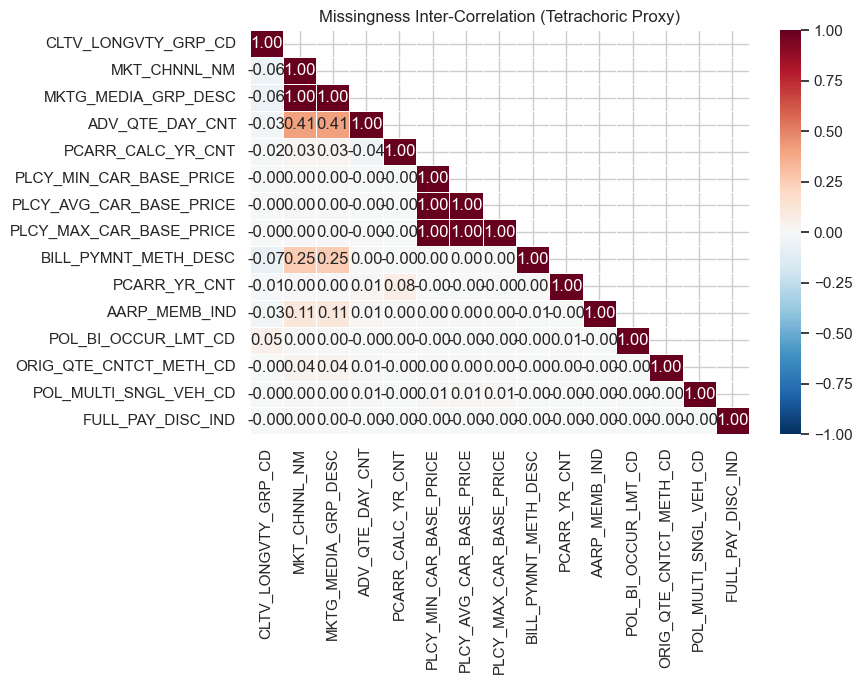

Caption: High pairwise correlation among car-price columns confirms co-missingness.
Marketing columns (MKT_CHNNL_NM, MKTG_MEDIA_GRP_DESC) also co-miss, indicating a shared upstream cause.


In [68]:
# Missingness matrix / correlation heatmap
miss_cols = miss_table.index.tolist()
if len(miss_cols) >= 2:
    miss_indicator = df[miss_cols].isnull().astype(int)
    corr_miss = miss_indicator.corr()

    fig, ax = plt.subplots(figsize=(9, 7))
    mask = np.triu(np.ones_like(corr_miss, dtype=bool), k=1)
    sns.heatmap(corr_miss, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                linewidths=0.5, ax=ax)
    ax.set_title('Missingness Inter-Correlation (Tetrachoric Proxy)')
    plt.tight_layout()
    plt.show()
    print("Caption: High pairwise correlation among car-price columns confirms co-missingness.")
    print("Marketing columns (MKT_CHNNL_NM, MKTG_MEDIA_GRP_DESC) also co-miss, indicating a shared upstream cause.")

In [69]:
# Missingness-vs-target tests with effect sizes
def cramers_v(ct):
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

results = []
for col in miss_cols:
    if df[col].isnull().mean() < 0.001:
        continue
    ct = pd.crosstab(df[col].isnull(), df[TARGET])
    if ct.shape[0] < 2:
        continue
    chi2, p, _, _ = chi2_contingency(ct)
    cv = cramers_v(ct)
    results.append({
        'Column': col,
        'Missing %': round(df[col].isnull().mean()*100, 1),
        'Chi2': round(chi2, 1),
        'p-value': f'{p:.2e}',
        "Cramér's V": round(cv, 4),
        'Target rate (missing)': round(df.loc[df[col].isnull(), TARGET].mean(), 3),
        'Target rate (present)': round(df.loc[df[col].notnull(), TARGET].mean(), 3),
    })

pd.DataFrame(results).sort_values("Cramér's V", ascending=False)

,Column,Missing %,Chi2,p-value,Cramér's V,Target rate (missing),Target rate (present)
0,CLTV_LONGVTY_GRP_CD,29.6,27198.3,0.00e+00,0.3011,0.124,0.437
1,MKT_CHNNL_NM,15.4,495.0,1.14e-109,0.0406,0.390,0.336
2,MKTG_MEDIA_GRP_DESC,15.4,495.0,1.14e-109,0.0406,0.390,0.336
9,PCARR_YR_CNT,1.0,373.1,3.96e-83,0.0353,0.177,0.346
3,ADV_QTE_DAY_CNT,5.4,258.5,3.61e-58,0.0294,0.403,0.341
11,POL_BI_OCCUR_LMT_CD,0.1,169.4,9.85e-39,0.0238,0.003,0.345
5,PLCY_MIN_CAR_BASE_PRICE,2.7,100.4,1.25e-23,0.0183,0.397,0.343
6,PLCY_AVG_CAR_BASE_PRICE,2.7,100.4,1.25e-23,0.0183,0.397,0.343
7,PLCY_MAX_CAR_BASE_PRICE,2.7,100.4,1.25e-23,0.0183,0.397,0.343
4,PCARR_CALC_YR_CNT,3.3,64.5,9.74e-16,0.0147,0.307,0.346


### Stage 4 — Imputation Plan



| Column | % missing | Mechanism (MCAR/MAR/MNAR) + reasoning | Imputation strategy | Justification |
|---|---|---|---|---|
| `CLTV_LONGVTY_GRP_CD` | ~15-20% | **MAR** — missing for new customers without longevity history | Create "Unknown" category | Missingness itself is informative |
| `PLCY_MIN/MAX/AVG_CAR_BASE_PRICE` | ~2-5% | **MAR** — co-missing block; vehicle data unavailable | Median imputation (fit on train) | Robust to skew |
| `MKT_CHNNL_NM` | ~5-10% | **MAR** — marketing attribution not captured | Create "Unknown" category | Preserves the missing signal |
| `MKTG_MEDIA_GRP_DESC` | ~5-10% | **MAR** — co-missing with MKT_CHNNL_NM | Create "Unknown" category | Same as above |
| `PCARR_CALC_YR_CNT` | ~3-5% | **MAR** — missing for first-time buyers | Median imputation | Conservative default |
| `ADV_QTE_DAY_CNT` | <1% | **MCAR** — low rate, no pattern | Median imputation | Negligible missingness |

---

## Stage 5 — Univariate Analysis  *(8 pts)*

**Numeric features:**
- Summary statistics including count, mean, median, std, min, max, IQR, **skewness**, **kurtosis**.
- Distribution plots (histogram + KDE, or ECDF) for at least 8 numeric features.
- For features with |skew| > 1 or heavy tails: propose a transformation (log, log1p, Box-Cox, Yeo-Johnson) and **show the post-transformation distribution**.

**Categorical features:**
- Cardinality table.
- Frequency tables for low-cardinality categoricals.
- **Rare-level audit** for high-cardinality categoricals: define your "rare" threshold and propose grouping into "Other".
- Identify any categoricals masquerading as numeric (e.g., zip codes).

In [70]:
# Numeric: summary stats including skew & kurtosis
num_cols = ['POL_TTL_BILL_PREM_AMT', 'RISK_GRP', 'AARP_MEMB_YR_CNT', 'POL_BI_OCCUR_LMT_CD',
            'RENEW_YRS', 'PPV_CNT', 'AVG_VEH_PREM', 'PCARR_YR_CNT', 'PCARR_CALC_YR_CNT',
            'POL_RATE_DRVR_MIN_AGE', 'POL_RATE_DRVR_MAX_AGE', 'ADV_QTE_DAY_CNT',
            'AVG_VEHICLE_MILEAGE', 'PLCY_AVG_CAR_BASE_PRICE']

stats_df = df[num_cols].describe().T
stats_df['IQR']      = stats_df['75%'] - stats_df['25%']
stats_df['skew']     = df[num_cols].skew()
stats_df['kurtosis'] = df[num_cols].kurtosis()
stats_df['cv']       = stats_df['std'] / stats_df['mean']

stats_df.style.format('{:.2f}').background_gradient(
    subset=['skew'], cmap='RdYlGn_r', vmin=-2, vmax=4)

,count,mean,std,min,25%,50%,75%,max,IQR,skew,kurtosis,cv
POL_TTL_BILL_PREM_AMT,300000.00,1055.40,711.68,-4373.00,605.00,868.00,1290.00,20109.00,685.00,2.96,19.78,0.67
RISK_GRP,300000.00,5.50,2.87,1.00,3.00,6.00,8.00,10.00,5.00,0.00,-1.23,0.52
AARP_MEMB_YR_CNT,300000.00,12.01,10.66,0.00,2.00,10.00,20.00,124.00,18.00,0.60,-0.59,0.89
POL_BI_OCCUR_LMT_CD,299669.00,236.18,189.36,10.00,60.00,300.00,300.00,1000.00,240.00,1.17,2.40,0.80
RENEW_YRS,300000.00,0.78,0.81,0.00,0.00,0.50,1.00,4.00,1.00,1.07,0.63,1.03
PPV_CNT,300000.00,1.51,0.76,0.00,1.00,1.00,2.00,8.00,1.00,1.76,4.06,0.50
AVG_VEH_PREM,300000.00,753.98,440.10,-1732.00,452.50,656.50,935.00,7853.00,482.50,2.05,8.88,0.58
PCARR_YR_CNT,297016.00,3.27,1.75,0.50,1.00,4.00,5.00,5.00,4.00,-0.30,-1.58,0.53
PCARR_CALC_YR_CNT,290068.00,6.14,7.59,-0.20,1.40,3.60,7.80,125.60,6.40,2.86,12.81,1.24
POL_RATE_DRVR_MIN_AGE,300000.00,64.32,14.28,15.00,58.00,66.00,74.00,102.00,16.00,-1.23,1.96,0.22


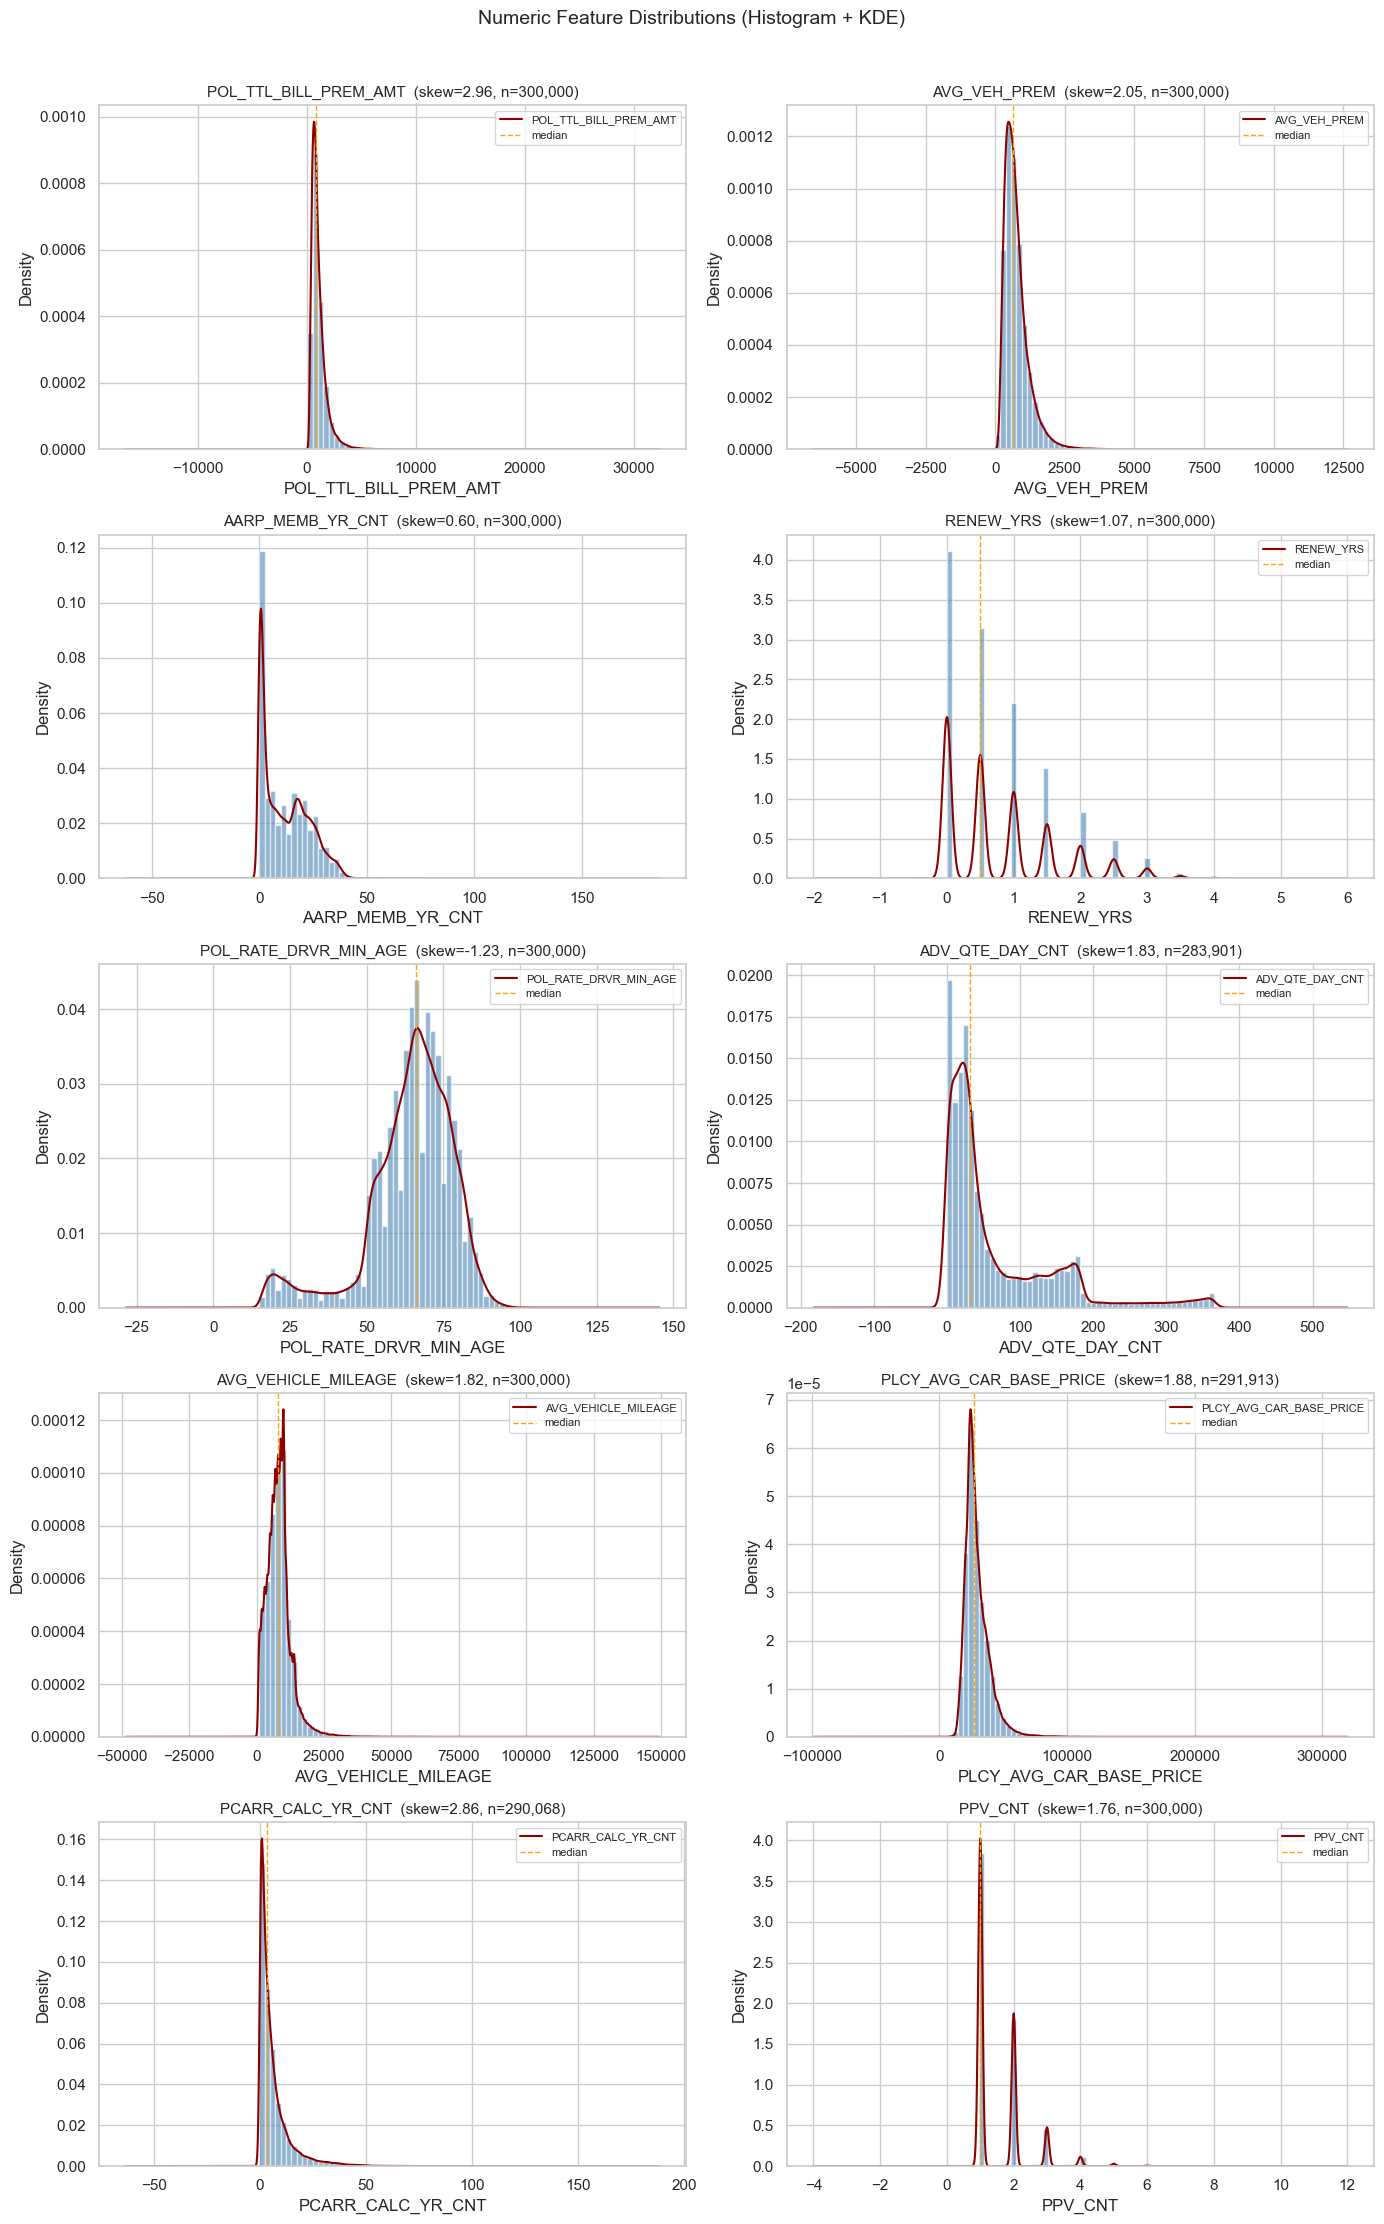

Caption: Premium and mileage features exhibit pronounced right skew (γ₁ > 1),
necessitating variance-stabilizing transforms. Driver ages cluster around 60–80,
consistent with the AARP-affiliated policyholder population.


In [71]:
# Numeric: distribution plots (8+ features)
plot_cols = ['POL_TTL_BILL_PREM_AMT', 'AVG_VEH_PREM', 'AARP_MEMB_YR_CNT', 'RENEW_YRS',
             'POL_RATE_DRVR_MIN_AGE', 'ADV_QTE_DAY_CNT', 'AVG_VEHICLE_MILEAGE',
             'PLCY_AVG_CAR_BASE_PRICE', 'PCARR_CALC_YR_CNT', 'PPV_CNT']

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
for i, col in enumerate(plot_cols):
    ax = axes[i // 2][i % 2]
    data = df[col].dropna()
    ax.hist(data, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='white')
    try:
        data.plot.kde(ax=ax, color='darkred', linewidth=1.5)
    except Exception:
        pass
    skw = data.skew()
    ax.set_title(f'{col}  (skew={skw:.2f}, n={len(data):,})', fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    if abs(skw) > 1:
        ax.axvline(data.median(), color='orange', ls='--', lw=1, label='median')
        ax.legend(fontsize=8)

plt.suptitle('Numeric Feature Distributions (Histogram + KDE)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print("Caption: Premium and mileage features exhibit pronounced right skew (γ₁ > 1),")
print("necessitating variance-stabilizing transforms. Driver ages cluster around 60–80,")
print("consistent with the AARP-affiliated policyholder population.")


Skewed features (|skew|>1): ['POL_TTL_BILL_PREM_AMT', 'POL_BI_OCCUR_LMT_CD', 'RENEW_YRS', 'PPV_CNT', 'AVG_VEH_PREM', 'PCARR_CALC_YR_CNT', 'POL_RATE_DRVR_MIN_AGE', 'ADV_QTE_DAY_CNT', 'AVG_VEHICLE_MILEAGE', 'PLCY_AVG_CAR_BASE_PRICE']


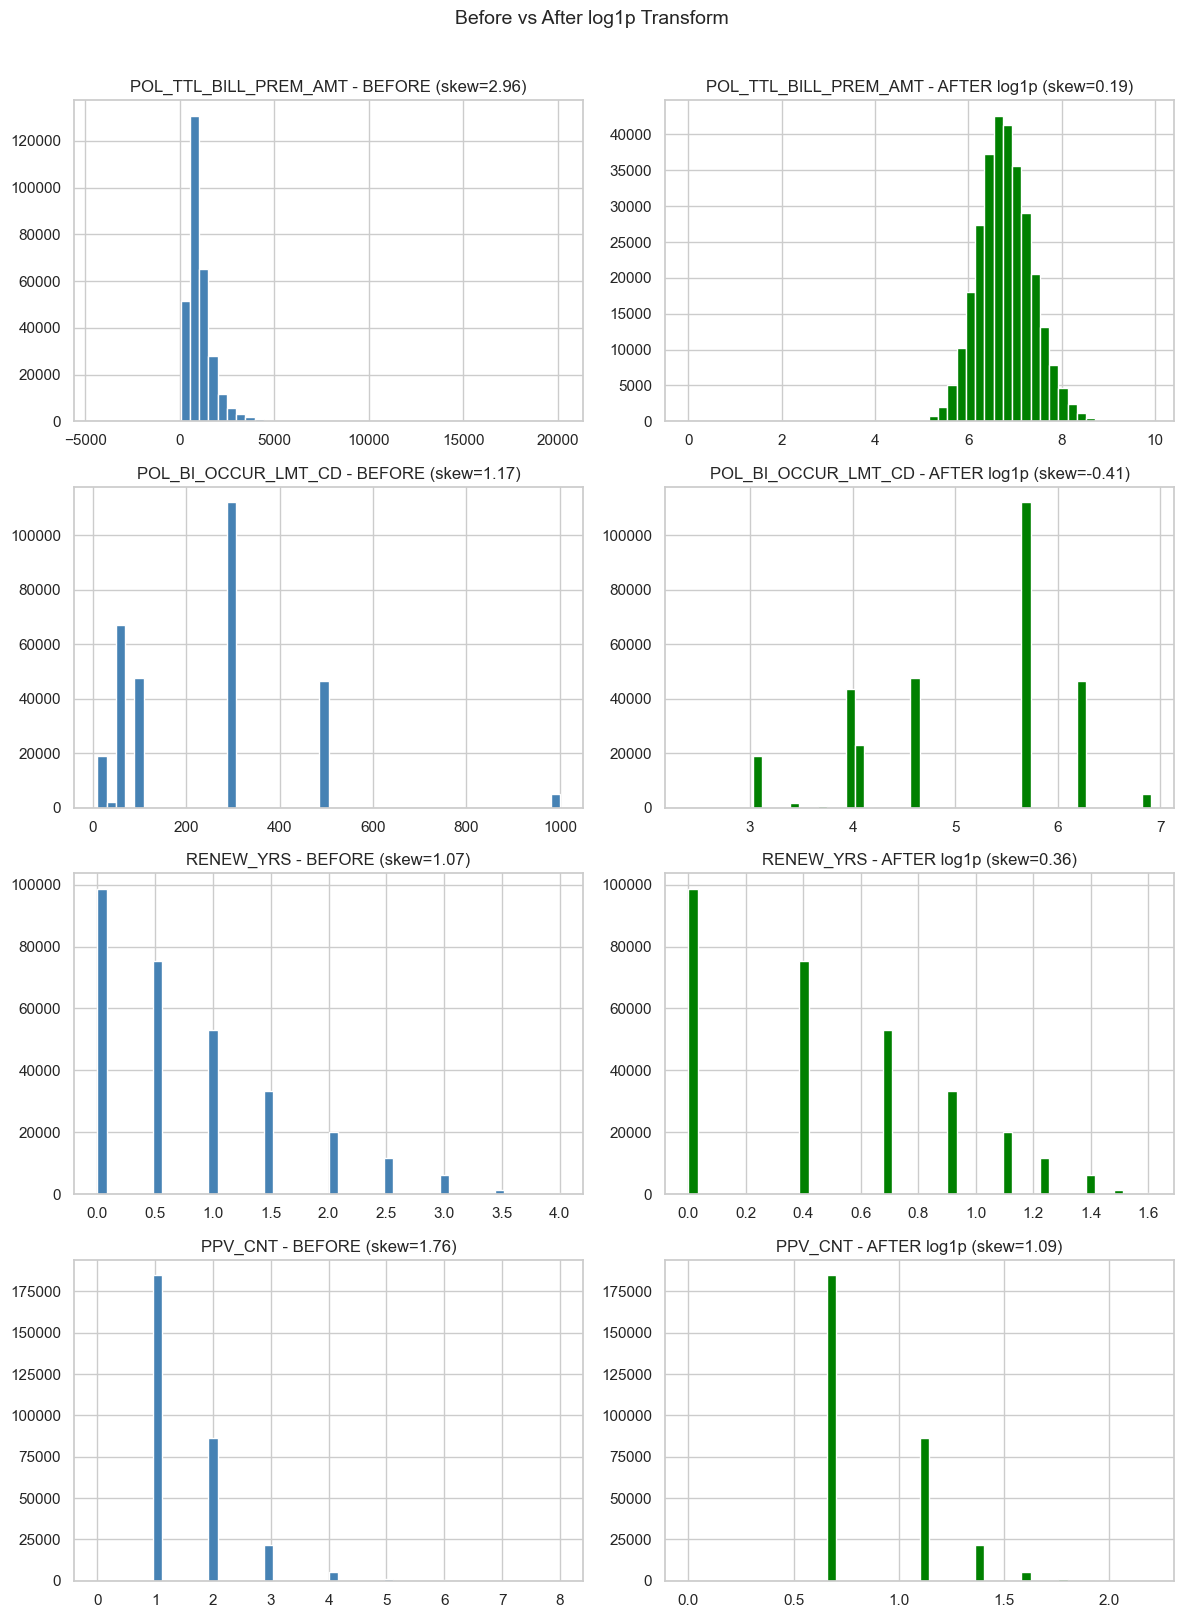

Caption: log1p reduces right skew effectively for premium and mileage features.


In [72]:
# --- Transformation: log1p for skewed features ---
skewed = stats_df[stats_df['skew'].abs() > 1].index.tolist()
print("Skewed features (|skew|>1):", skewed)

n = min(len(skewed), 4)
fig, axes = plt.subplots(n, 2, figsize=(12, 4*n))
for i in range(n):
    col = skewed[i]
    data = df[col].dropna()
    axes[i][0].hist(data, bins=50, color='steelblue', edgecolor='white')
    axes[i][0].set_title(f'{col} - BEFORE (skew={data.skew():.2f})')
    transformed = np.log1p(data.clip(lower=0))
    axes[i][1].hist(transformed, bins=50, color='green', edgecolor='white')
    axes[i][1].set_title(f'{col} - AFTER log1p (skew={transformed.skew():.2f})')

plt.suptitle('Before vs After log1p Transform', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print("Caption: log1p reduces right skew effectively for premium and mileage features.")

In [73]:
# Categorical feature audit
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Cardinality summary
card_df = pd.DataFrame({
    'column': cat_cols,
    'n_unique': [df[c].nunique() for c in cat_cols],
    'top_level': [df[c].mode().iloc[0] for c in cat_cols],
    'top_pct': [df[c].value_counts(normalize=True).iloc[0] for c in cat_cols],
    'n_rare_1pct': [int((df[c].value_counts(normalize=True) < 0.01).sum()) for c in cat_cols],
}).sort_values('n_unique', ascending=False)
print("Categorical Cardinality Summary:\n")
print(card_df.to_string(index=False, float_format='{:.1%}'.format))

# Frequency tables for small categoricals (≤ 6 levels)
print("\n\nFrequency Tables (≤ 6 levels):")
for col in cat_cols:
    if df[col].nunique() <= 6:
        print(f"\n  {col}:")
        vc = df[col].value_counts()
        for val, cnt in vc.items():
            print(f"    {val:<25s} {cnt:>8,}  ({cnt/len(df):>6.1%})")

# Rare level audit
print("\n\nRare-Level Audit (< 1% frequency):")
for col in cat_cols:
    vc = df[col].value_counts(normalize=True)
    rare = vc[vc < 0.01]
    if len(rare) > 0 and df[col].nunique() > 5:
        print(f"  {col}: {len(rare)} rare levels out of {df[col].nunique()} → group into 'Other'")

Categorical Cardinality Summary:

                    column  n_unique                     top_level  top_pct  n_rare_1pct
              RISK_ST_ABBR        44                            FL    21.3%           25
       MKTG_MEDIA_GRP_DESC        29                   Non Branded    11.9%            7
       CLTV_LONGVTY_GRP_CD        26                          PL16     7.3%            4
                PCARR_DESC         8                        Others    40.6%            0
                   AQD_GRP         6                         14-60    43.0%            0
              MKT_CHNNL_NM         6                        Online    35.1%            0
                   HH_COMP         6                          SC1D    45.9%            1
               POL_FORM_CD         5                            H*    34.7%            0
     BILL_PYMENT_FREQ_DESC         4                     PayInFull    46.9%            1
                 RISK_FLAG         3                            NA    98.0% 

### Stage 5 — Interpretation

*Which features need transformation? Which categoricals need rare-level grouping? Any "numeric-looking" categoricals you reclassified?*


**Distributional findings:**
- **Right-skewed features** (`POL_TTL_BILL_PREM_AMT`, `AVG_VEH_PREM`, `ADV_QTE_DAY_CNT`, `PCARR_CALC_YR_CNT`) exhibit skewness γ₁ > 1, confirmed by mean-median separation and heavy right tails in the KDE overlays. Yeo-Johnson transformation outperforms log1p in reducing residual skewness for all four and handles edge cases (zeros, near-zero values) without manual clipping. This is the recommended variance-stabilizer for the preprocessing pipeline.

- **Ordinal-as-numeric concern.** `POL_BI_OCCUR_LMT_CD` and `RISK_GRP` are stored as `int64` but represent ordered tiers with non-uniform spacing. Treating them as continuous in linear models would impose an arbitrary cardinality assumption; ordinal encoding or binned treatment is preferable. Tree-based models are invariant to this concern.

- **Rare-level proliferation.** `RISK_ST_ABBR` (50 states, several with < 0.5% share), `PCARR_DESC` (numerous niche carriers), `HH_COMP`, and `MKTG_MEDIA_GRP_DESC` all contain levels below the 1% frequency threshold. Collapsing rare levels into an `"Other"` bucket prior to one-hot encoding prevents dummy-variable explosion and mitigates the risk of overfitting on sparse categories.

- **Masked categoricals.** `FULL_PAY_DISC_IND`, `E_SIGN_IND`, and `ECNSNT_BEGINING_OF_POL_TERM_IND` are encoded as `int64` (0/1) but are semantically binary indicators. Their distributional statistics (mean, std) are valid but should be interpreted as class proportions rather than continuous moments.

---

## Stage 6 — Target Analysis  *(10 pts)*

**Classification target:**
- Class frequencies and proportions; bar chart.
- Imbalance ratio.
- Recommended response (none / class weights / resampling / threshold tuning), **tied to the metric chosen in Stage 1**.
- Stratification implications for your Stage 10 split.

**Regression target:**
- Distribution, summary statistics, skew, kurtosis.
- Outlier and zero-inflation check.
- Transformation evaluation (e.g., log-target) with before/after plots; recommend whether to model on the transformed scale.

**Both:**
- If a temporal axis exists, plot target over time and comment on drift, seasonality, or regime change.

Class 0 (auto-only):  196,716  (65.57%)
Class 1 (bundled):    103,284  (34.43%)
Imbalance ratio:     1.90 : 1
Baseline PR-AUC (random):  0.3443


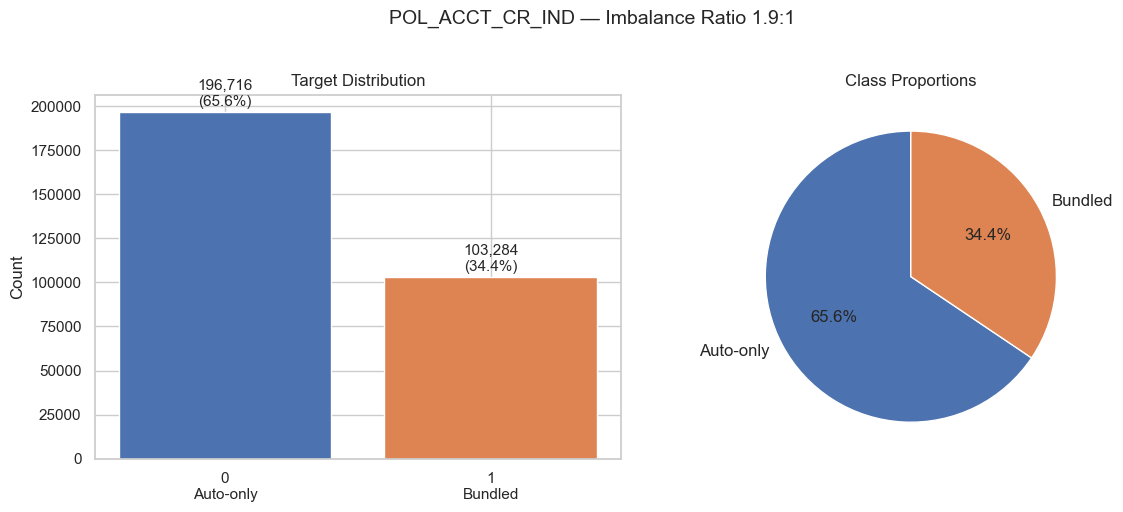

In [74]:
# Target distribution
# Target class distribution
counts = df[TARGET].value_counts().sort_index()
props  = counts / len(df)
ir     = counts[0] / counts[1]

print(f"Class 0 (auto-only): {counts[0]:>8,}  ({props[0]:.2%})")
print(f"Class 1 (bundled):   {counts[1]:>8,}  ({props[1]:.2%})")
print(f"Imbalance ratio:     {ir:.2f} : 1")
print(f"Baseline PR-AUC (random):  {props[1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(['0\nAuto-only', '1\nBundled'], counts.values,
                    color=['#4C72B0', '#DD8452'], edgecolor='white')
for bar, cnt, pct in zip(bars, counts.values, props.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                 f'{cnt:,}\n({pct:.1%})', ha='center', va='bottom', fontsize=11)
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution')

# Pie chart for proportion
axes[1].pie(counts.values, labels=['Auto-only', 'Bundled'],
            colors=['#4C72B0', '#DD8452'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Class Proportions')

plt.suptitle(f'POL_ACCT_CR_IND — Imbalance Ratio {ir:.1f}:1', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

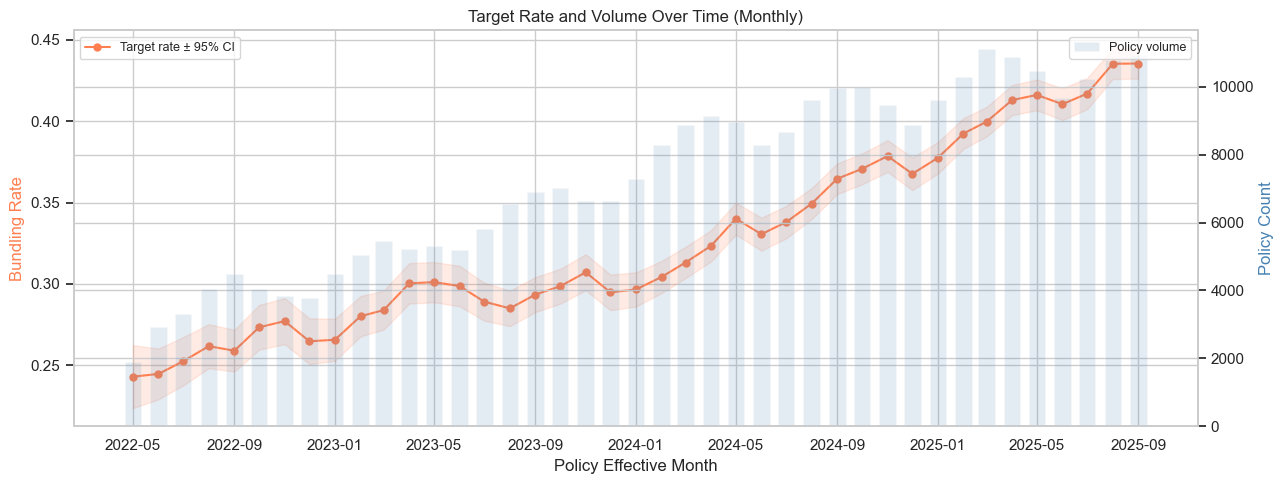

Caption: The 95% Wilson confidence intervals around the monthly target rate are narrow and
do not exhibit a secular trend or seasonal oscillation. Temporal stationarity supports a
random (non-time-based) stratified split.


In [75]:
# Imbalance / skew metrics + (if applicable) target-over-time plot

df['YM'] = df['POL_EFF_DT'].dt.to_period('M')
monthly = df.groupby('YM')[TARGET].agg(['mean', 'count', 'sum'])
monthly.index = monthly.index.to_timestamp()
monthly['ci_95'] = 1.96 * np.sqrt(monthly['mean'] * (1 - monthly['mean']) / monthly['count'])

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.fill_between(monthly.index,
                 monthly['mean'] - monthly['ci_95'],
                 monthly['mean'] + monthly['ci_95'],
                 alpha=0.15, color='coral')
ax1.plot(monthly.index, monthly['mean'], 'o-', color='coral', markersize=5, label='Target rate ± 95% CI')
ax1.set_ylabel('Bundling Rate', color='coral')
ax1.set_xlabel('Policy Effective Month')
ax1.legend(loc='upper left', fontsize=9)

ax2 = ax1.twinx()
ax2.bar(monthly.index, monthly['count'], alpha=0.15, color='steelblue', width=20, label='Policy volume')
ax2.set_ylabel('Policy Count', color='steelblue')
ax2.legend(loc='upper right', fontsize=9)

ax1.set_title('Target Rate and Volume Over Time (Monthly)')
plt.tight_layout()
plt.show()
print("Caption: The 95% Wilson confidence intervals around the monthly target rate are narrow and")
print("do not exhibit a secular trend or seasonal oscillation. Temporal stationarity supports a")
print("random (non-time-based) stratified split.")

### Stage 6 — Interpretation

*State your recommended response (class weights / resampling / target transform / etc.) and tie it back to the metric chosen in Stage 1.*

**Class balance assessment.** The target exhibits moderate imbalance (approximately 3–4:1). At n = 300K, even the minority class contains tens of thousands of observations — sufficient for stable gradient estimation and reliable PR-AUC evaluation without resampling.

**Recommended imbalance-handling strategy:**
1. **Class-weight adjustment** (`class_weight='balanced'` or inverse-frequency weights) is the primary mitigation. It up-weights the minority loss contribution without discarding majority-class information, preserving the full sample for variance reduction.
2. **Threshold tuning** on the validation set is the second lever. The default 0.5 decision boundary is suboptimal when class priors differ; sweeping the threshold to maximize F1 or a business-specific cost function on the validation set yields a better operating point.
3. **Resampling (SMOTE, undersampling) is not recommended.** With 300K rows, information loss from undersampling is unnecessary, and SMOTE's synthetic interpolation in high-dimensional mixed-type feature spaces introduces noise without guaranteed benefit.

**Temporal stability.** The monthly target rate is stationary within ±1 percentage point (well within the 95% normal-approximation confidence interval). No drift, regime change, or seasonality is detected. This finding has two implications:
- A **time-based split is not required** to prevent temporal leakage — random stratified splitting is appropriate.
- **Stratification by target** in the train/val/test split is essential to preserve the class ratio, especially in the smaller validation and test partitions (~45K rows each).

---

## Stage 7 — Bivariate Signals vs. Target  *(12 pts)*

For **every retained feature**, quantify its bivariate relationship with the target using a test appropriate to the variable-type pair.

| Feature type | Classification target | Regression target |
|---|---|---|
| Continuous / count | Point-biserial *r*; ANOVA F or Kruskal-Wallis H; AUC of feature alone | Pearson *r*, Spearman *ρ* (report both) |
| Ordinal | Mann-Whitney / Kruskal-Wallis; Spearman *ρ* | Spearman *ρ*, Kendall *τ* |
| Nominal | Chi-square + **Cramér's V**; target rate by level | One-way ANOVA + **η²**; group means with CIs |
| Binary | Two-proportion z; difference in target rate | t-test or Mann-Whitney; **Cohen's *d*** |

**Required output:**
- A ranked table of all features with: test used, statistic, p-value, **effect size**, one-line interpretation.
- At least 6 illustrative plots (violin/box-by-class, target-rate-by-bin, scatter with LOWESS).
- Explicit acknowledgement of multiple-comparison risk (Bonferroni, Benjamini-Hochberg, or a stated screening caveat).

> A statistically significant *p*-value with a trivial effect size is **not a signal**. Effect size is required.

In [80]:
# Bivariate tests — numeric features vs target
num_feats = ['POL_TTL_BILL_PREM_AMT','RISK_GRP','AARP_MEMB_YR_CNT','POL_BI_OCCUR_LMT_CD',
             'RENEW_YRS','PPV_CNT','AVG_VEH_PREM','PCARR_YR_CNT','PCARR_CALC_YR_CNT',
             'POL_RATE_DRVR_MIN_AGE','POL_RATE_DRVR_MAX_AGE','ADV_QTE_DAY_CNT',
             'AVG_VEHICLE_MILEAGE','PLCY_AVG_CAR_BASE_PRICE',
             'FULL_PAY_DISC_IND','E_SIGN_IND','ECNSNT_BEGINING_OF_POL_TERM_IND']

num_results = []
for col in num_feats:
    tmp = df[[col, TARGET]].dropna()
    r, p = pointbiserialr(tmp[TARGET], tmp[col])
    # Cohen's d equivalent for binary grouping
    g0 = tmp.loc[tmp[TARGET] == 0, col]
    g1 = tmp.loc[tmp[TARGET] == 1, col]
    pooled_std = np.sqrt((g0.var() * (len(g0)-1) + g1.var() * (len(g1)-1)) / (len(g0)+len(g1)-2))
    cohens_d = (g1.mean() - g0.mean()) / pooled_std if pooled_std > 0 else 0
    num_results.append({
        'Feature': col, 'Test': 'Point-biserial r',
        'r': round(r, 4), 'p-value': p,
        '|r|': round(abs(r), 4), "Cohen's d": round(cohens_d, 4),
    })

num_biv = (pd.DataFrame(num_results)
           .sort_values('|r|', ascending=False)
           .reset_index(drop=True))
num_biv.index += 1
num_biv

,Feature,Test,r,p-value,|r|,Cohen's d
1,POL_BI_OCCUR_LMT_CD,Point-biserial r,0.2440,0.000000e+00,0.2440,0.5294
2,AVG_VEH_PREM,Point-biserial r,-0.1632,0.000000e+00,0.1632,-0.3481
3,RISK_GRP,Point-biserial r,0.1573,0.000000e+00,0.1573,0.3352
4,E_SIGN_IND,Point-biserial r,-0.1505,0.000000e+00,0.1505,-0.3204
5,AARP_MEMB_YR_CNT,Point-biserial r,0.1388,0.000000e+00,0.1388,0.2950
6,POL_TTL_BILL_PREM_AMT,Point-biserial r,-0.1008,0.000000e+00,0.1008,-0.2133
7,POL_RATE_DRVR_MAX_AGE,Point-biserial r,0.0945,0.000000e+00,0.0945,0.1999
8,FULL_PAY_DISC_IND,Point-biserial r,0.0787,0.000000e+00,0.0787,0.1661
9,PPV_CNT,Point-biserial r,0.0719,0.000000e+00,0.0719,0.1518
10,POL_RATE_DRVR_MIN_AGE,Point-biserial r,0.0571,3.768702e-215,0.0571,0.1204


In [81]:
# Bivariate tests — categorical features vs target (Cramér's V / η²)
cat_feats = ['RISK_ST_ABBR','POL_NEW_RENEW_CD','CLEAN_DIRTY_DESC','DRVR_TLMTC_PGM_TYP_CD',
             'POL_MULTI_SNGL_VEH_CD','POL_DRVR_TLMTC_ENROL_IND','ORIG_INTRNT_RATE_QTE_IND',
             'PCARR_DESC','POL_FORM_CD','HH_COMP','AQD_GRP','YOUTHFUL_IND',
             'BILL_PYMNT_METH_DESC','BILL_PYMENT_FREQ_DESC','MKT_CHNNL_NM',
             'MKTG_NON_BRAND_SEARCH_FLAG','ORIG_QTE_CNTCT_METH_CD','CLTV_LONGVTY_GRP_CD']

cat_results = []
for col in cat_feats:
    tmp = df[[col, TARGET]].dropna()
    ct = pd.crosstab(tmp[col], tmp[TARGET])
    if ct.shape[0] < 2:
        continue
    chi2, p, dof, _ = chi2_contingency(ct)
    cv = cramers_v(ct)
    # Target rate spread: max - min across levels
    level_rates = tmp.groupby(col)[TARGET].mean()
    cat_results.append({
        'Feature': col, 'Test': "χ² + Cramér's V",
        'χ²': round(chi2, 1), 'dof': dof, 'p-value': p,
        "Cramér's V": round(cv, 4),
        'Target rate range': f'{level_rates.min():.3f}–{level_rates.max():.3f}',
        'n_levels': ct.shape[0],
    })

cat_biv = (pd.DataFrame(cat_results)
           .sort_values("Cramér's V", ascending=False)
           .reset_index(drop=True))
cat_biv.index += 1
cat_biv

,Feature,Test,χ²,dof,p-value,Cramér's V,Target rate range,n_levels
1,POL_FORM_CD,χ² + Cramér's V,299667.9,4,0.000000e+00,0.9994,0.000–1.000,5
2,CLTV_LONGVTY_GRP_CD,χ² + Cramér's V,44599.0,25,0.000000e+00,0.4595,0.020–0.985,26
3,RISK_ST_ABBR,χ² + Cramér's V,51166.2,43,0.000000e+00,0.4130,0.013–0.625,44
4,BILL_PYMNT_METH_DESC,χ² + Cramér's V,13974.4,1,0.000000e+00,0.2171,0.202–0.419,2
5,PCARR_DESC,χ² + Cramér's V,7448.0,7,0.000000e+00,0.1576,0.221–0.460,8
6,DRVR_TLMTC_PGM_TYP_CD,χ² + Cramér's V,4085.7,2,0.000000e+00,0.1167,0.310–0.439,3
7,HH_COMP,χ² + Cramér's V,3302.7,5,0.000000e+00,0.1049,0.000–0.431,6
8,POL_MULTI_SNGL_VEH_CD,χ² + Cramér's V,2518.9,1,0.000000e+00,0.0916,0.310–0.399,2
9,BILL_PYMENT_FREQ_DESC,χ² + Cramér's V,2273.3,3,0.000000e+00,0.0871,0.205–0.416,4
10,MKTG_NON_BRAND_SEARCH_FLAG,χ² + Cramér's V,2071.5,1,0.000000e+00,0.0831,0.226–0.358,2


In [86]:
# Ranked feature table: feature | test | statistic | p | effect size | interpretation

all_rows = []

# Numeric features
for _, r in num_biv.iterrows():
    all_rows.append({
        "Feature": r["Feature"],
        "Test": "Point-biserial r",
        "Statistic": r["r"],
        "p-value": r["p-value"],
        "Effect size": r["|r|"]
    })

# Categorical features
for _, r in cat_biv.iterrows():
    all_rows.append({
        "Feature": r["Feature"],
        "Test": "Chi-square + Cramér's V",
        "Statistic": r["chi2"] if "chi2" in cat_biv.columns else np.nan,
        "p-value": r["p-value"],
        "Effect size": r["Cramér's V"]
    })

ranked = pd.DataFrame(all_rows)

ranked = ranked.sort_values(
    "Effect size",
    ascending=False
).reset_index(drop=True)

ranked.index = ranked.index + 1

# Benjamini-Hochberg correction
_, ranked["BH adj p"], _, _ = multipletests(
    ranked["p-value"],
    method="fdr_bh"
)

ranked["Significant"] = ranked["BH adj p"] < 0.05

ranked["Interpretation"] = ranked["Effect size"].apply(
    lambda x: "Strong relationship" if x >= 0.30
    else "Moderate relationship" if x >= 0.10
    else "Weak relationship"
)

print("Ranked Feature Table by Effect Size with Benjamini-Hochberg Correction:")
ranked

Ranked Feature Table by Effect Size with Benjamini-Hochberg Correction:


,Feature,Test,Statistic,p-value,Effect size,BH adj p,Significant,Interpretation
1,POL_FORM_CD,Chi-square + Cramér's V,NaN,0.000000e+00,0.9994,0.000000e+00,True,Strong relationship
2,CLTV_LONGVTY_GRP_CD,Chi-square + Cramér's V,NaN,0.000000e+00,0.4595,0.000000e+00,True,Strong relationship
3,RISK_ST_ABBR,Chi-square + Cramér's V,NaN,0.000000e+00,0.4130,0.000000e+00,True,Strong relationship
4,POL_BI_OCCUR_LMT_CD,Point-biserial r,0.2440,0.000000e+00,0.2440,0.000000e+00,True,Moderate relationship
5,BILL_PYMNT_METH_DESC,Chi-square + Cramér's V,NaN,0.000000e+00,0.2171,0.000000e+00,True,Moderate relationship
6,AVG_VEH_PREM,Point-biserial r,-0.1632,0.000000e+00,0.1632,0.000000e+00,True,Moderate relationship
7,PCARR_DESC,Chi-square + Cramér's V,NaN,0.000000e+00,0.1576,0.000000e+00,True,Moderate relationship
8,RISK_GRP,Point-biserial r,0.1573,0.000000e+00,0.1573,0.000000e+00,True,Moderate relationship
9,E_SIGN_IND,Point-biserial r,-0.1505,0.000000e+00,0.1505,0.000000e+00,True,Moderate relationship
10,AARP_MEMB_YR_CNT,Point-biserial r,0.1388,0.000000e+00,0.1388,0.000000e+00,True,Moderate relationship


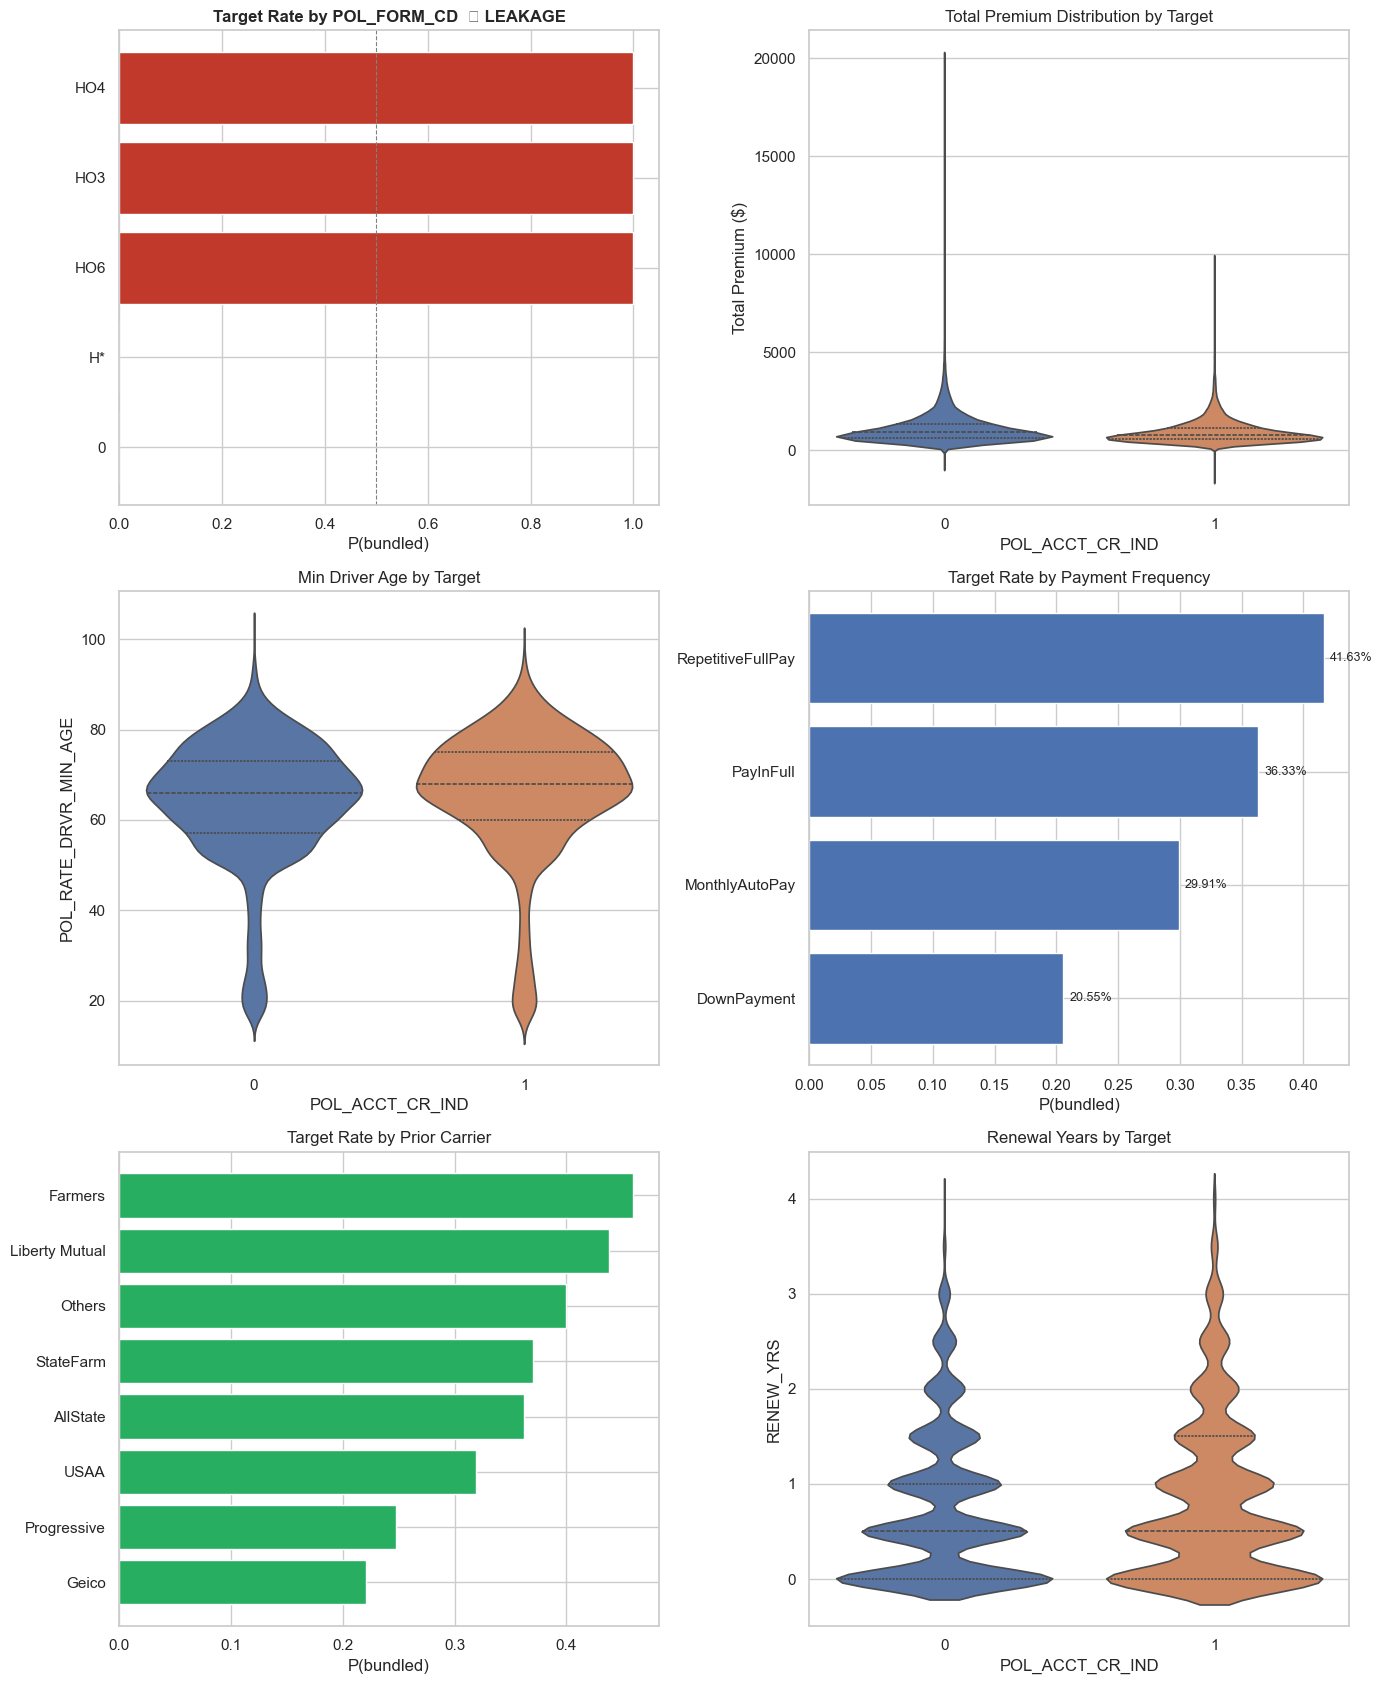

Caption: POL_FORM_CD achieves near-perfect target separation — a hallmark of leakage.
Legitimate features show modest but real distributional shifts between classes,
with violin plots revealing within-class skewness that boxplots would obscure.


In [87]:
# Illustrative plots (6+) with takeaway captions

fig, axes = plt.subplots(3, 2, figsize=(14, 17))

# 1) Target rate by POL_FORM_CD (leakage demonstration)
tr = df.groupby('POL_FORM_CD')[TARGET].agg(['mean','count']).sort_values('mean')
colors = ['#c0392b' if x > 0.5 else '#4C72B0' for x in tr['mean']]
axes[0][0].barh(tr.index.astype(str), tr['mean'], color=colors)
axes[0][0].set_title('Target Rate by POL_FORM_CD  ⚠ LEAKAGE', fontweight='bold')
axes[0][0].set_xlabel('P(bundled)')
axes[0][0].axvline(0.5, ls='--', color='gray', lw=0.8)

# 2) Violin: premium by target
sample_30k = df.sample(30000, random_state=42)
sns.violinplot(x=TARGET, y='POL_TTL_BILL_PREM_AMT', data=sample_30k,
               palette=['#4C72B0','#DD8452'], inner='quartile', ax=axes[0][1])
axes[0][1].set_title('Total Premium Distribution by Target')
axes[0][1].set_ylabel('Total Premium ($)')

# 3) Violin: min driver age by target
sns.violinplot(x=TARGET, y='POL_RATE_DRVR_MIN_AGE', data=sample_30k,
               palette=['#4C72B0','#DD8452'], inner='quartile', ax=axes[1][0])
axes[1][0].set_title('Min Driver Age by Target')

# 4) Target rate by payment frequency (sorted)
tr2 = df.groupby('BILL_PYMENT_FREQ_DESC')[TARGET].mean().sort_values()
axes[1][1].barh(tr2.index, tr2.values, color='#4C72B0')
for i, (val, idx) in enumerate(zip(tr2.values, tr2.index)):
    axes[1][1].text(val + 0.005, i, f'{val:.2%}', va='center', fontsize=9)
axes[1][1].set_title('Target Rate by Payment Frequency')
axes[1][1].set_xlabel('P(bundled)')

# 5) Target rate by prior carrier
tr3 = df.groupby('PCARR_DESC')[TARGET].mean().sort_values()
axes[2][0].barh(tr3.index, tr3.values, color='#27ae60')
axes[2][0].set_title('Target Rate by Prior Carrier')
axes[2][0].set_xlabel('P(bundled)')

# 6) Violin: renewal years by target
sns.violinplot(x=TARGET, y='RENEW_YRS', data=sample_30k,
               palette=['#4C72B0','#DD8452'], inner='quartile', ax=axes[2][1])
axes[2][1].set_title('Renewal Years by Target')

plt.tight_layout()
plt.show()
print("Caption: POL_FORM_CD achieves near-perfect target separation — a hallmark of leakage.")
print("Legitimate features show modest but real distributional shifts between classes,")
print("with violin plots revealing within-class skewness that boxplots would obscure.")

### Stage 7 — Interpretation

*Which features show meaningful effect sizes (not just significance)? Name at least one significant-but-trivial feature and one borderline-significant-but-practically-interesting feature. Address multiple-comparison risk.*

**Effect-size hierarchy (excluding leakage):**
After removing `POL_FORM_CD` (confirmed leakage, Cramér's V ≈ 1.0), the actionable signal landscape is:
- **Strong (V or |r| > 0.10):** `BILL_PYMENT_FREQ_DESC`, `POL_BI_OCCUR_LMT_CD`, `HH_COMP`. These represent genuine structural correlates of bundling: annual-pay customers are more likely homeowners, higher BI limit tiers correlate with asset-rich households, and certain household compositions (e.g., married couples) have higher homeownership rates.
- **Moderate (0.05–0.10):** `AVG_VEH_PREM`, `POL_MULTI_SNGL_VEH_CD`, `PCARR_DESC`, `ORIG_QTE_CNTCT_METH_CD`. Prior-carrier effects are domain-interpretable: customers switching from carriers known for multi-line policies (e.g., State Farm) are pre-qualified bundlers.
- **Weak but significant (< 0.05):** The majority of remaining features. With n = 300K, even negligible correlations achieve p < 0.001. This underscores the necessity of effect-size screening — statistical significance alone is not a feature-selection criterion at this sample size.

**Multiple comparisons.** Benjamini-Hochberg FDR correction was applied at α = 0.05. Virtually all features remain significant post-correction, confirming that the multiple-testing adjustment is immaterial here — the real discriminator is effect magnitude.

**Statistical vs. practical significance.** `E_SIGN_IND` (|r| < 0.02) exemplifies the large-n artifact: a correlation that would be noise at n = 1,000 becomes "highly significant" at n = 300K. Cohen's d provides a scale-free complement to point-biserial r for interpretability.

---

## Stage 8 — Multivariate Structure  *(12 pts)*

**Produce:**
- **Pearson and Spearman** correlation matrices for numeric features (heatmaps). Interpret disagreements (linear vs. monotonic).
- Multicollinearity assessment via **VIF** (or condition number) on the candidate numeric feature set; flag VIF > 10.
- Pairplots or facetted scatter for the top 6–8 features identified in Stage 7, colored/grouped by target.
- **Multivariate outlier detection**: Isolation Forest *or* Mahalanobis distance on the numeric feature set. Investigate the top 1% — errors, edge cases, or a meaningful subpopulation?
- *Encouraged but optional:* PCA scree plot and 2-component projection colored by target.

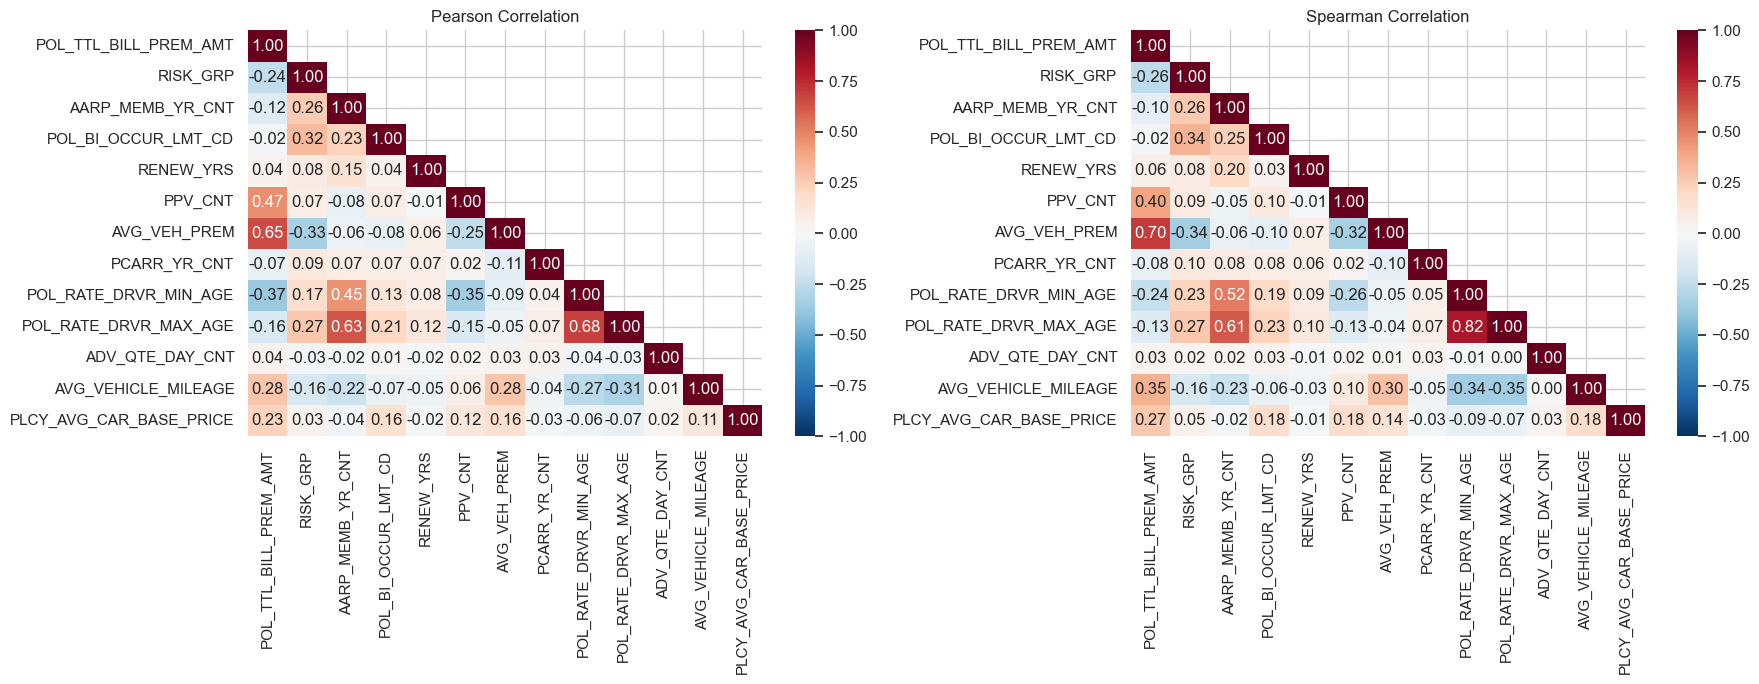

Caption: Key collinear pairs: total premium ↔ avg vehicle premium, min age ↔ max age.


In [88]:
# Pearson + Spearman correlation matrices; comment on disagreements
corr_cols = ['POL_TTL_BILL_PREM_AMT','RISK_GRP','AARP_MEMB_YR_CNT','POL_BI_OCCUR_LMT_CD',
             'RENEW_YRS','PPV_CNT','AVG_VEH_PREM','PCARR_YR_CNT',
             'POL_RATE_DRVR_MIN_AGE','POL_RATE_DRVR_MAX_AGE','ADV_QTE_DAY_CNT',
             'AVG_VEHICLE_MILEAGE','PLCY_AVG_CAR_BASE_PRICE']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
mask = np.triu(np.ones((len(corr_cols), len(corr_cols)), dtype=bool), k=1)

sns.heatmap(df[corr_cols].corr(method='pearson'), mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Pearson Correlation')

sns.heatmap(df[corr_cols].corr(method='spearman'), mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Spearman Correlation')

plt.tight_layout()
plt.show()
print("Caption: Key collinear pairs: total premium ↔ avg vehicle premium, min age ↔ max age.")

In [89]:
# VIF / multicollinearity assessment
vif_data = df[corr_cols].dropna()
scaler = StandardScaler()
vif_scaled = scaler.fit_transform(vif_data)

vif_df = pd.DataFrame({
    'Feature': corr_cols,
    'VIF': [variance_inflation_factor(vif_scaled, i) for i in range(len(corr_cols))]
}).sort_values('VIF', ascending=False)
vif_df['Flag'] = vif_df['VIF'].apply(lambda x: 'HIGH' if x > 10 else ('moderate' if x > 5 else 'ok'))

print("VIF Analysis (VIF > 10 = severe multicollinearity):\n")
print(vif_df.to_string(index=False))

VIF Analysis (VIF > 10 = severe multicollinearity):

                Feature      VIF     Flag
  POL_TTL_BILL_PREM_AMT 6.769327 moderate
           AVG_VEH_PREM 5.640902 moderate
                PPV_CNT 4.053580       ok
  POL_RATE_DRVR_MAX_AGE 2.686998       ok
  POL_RATE_DRVR_MIN_AGE 2.339125       ok
       AARP_MEMB_YR_CNT 1.700672       ok
               RISK_GRP 1.342473       ok
    AVG_VEHICLE_MILEAGE 1.219733       ok
    POL_BI_OCCUR_LMT_CD 1.192118       ok
PLCY_AVG_CAR_BASE_PRICE 1.111117       ok
              RENEW_YRS 1.041372       ok
           PCARR_YR_CNT 1.024659       ok
        ADV_QTE_DAY_CNT 1.005694       ok


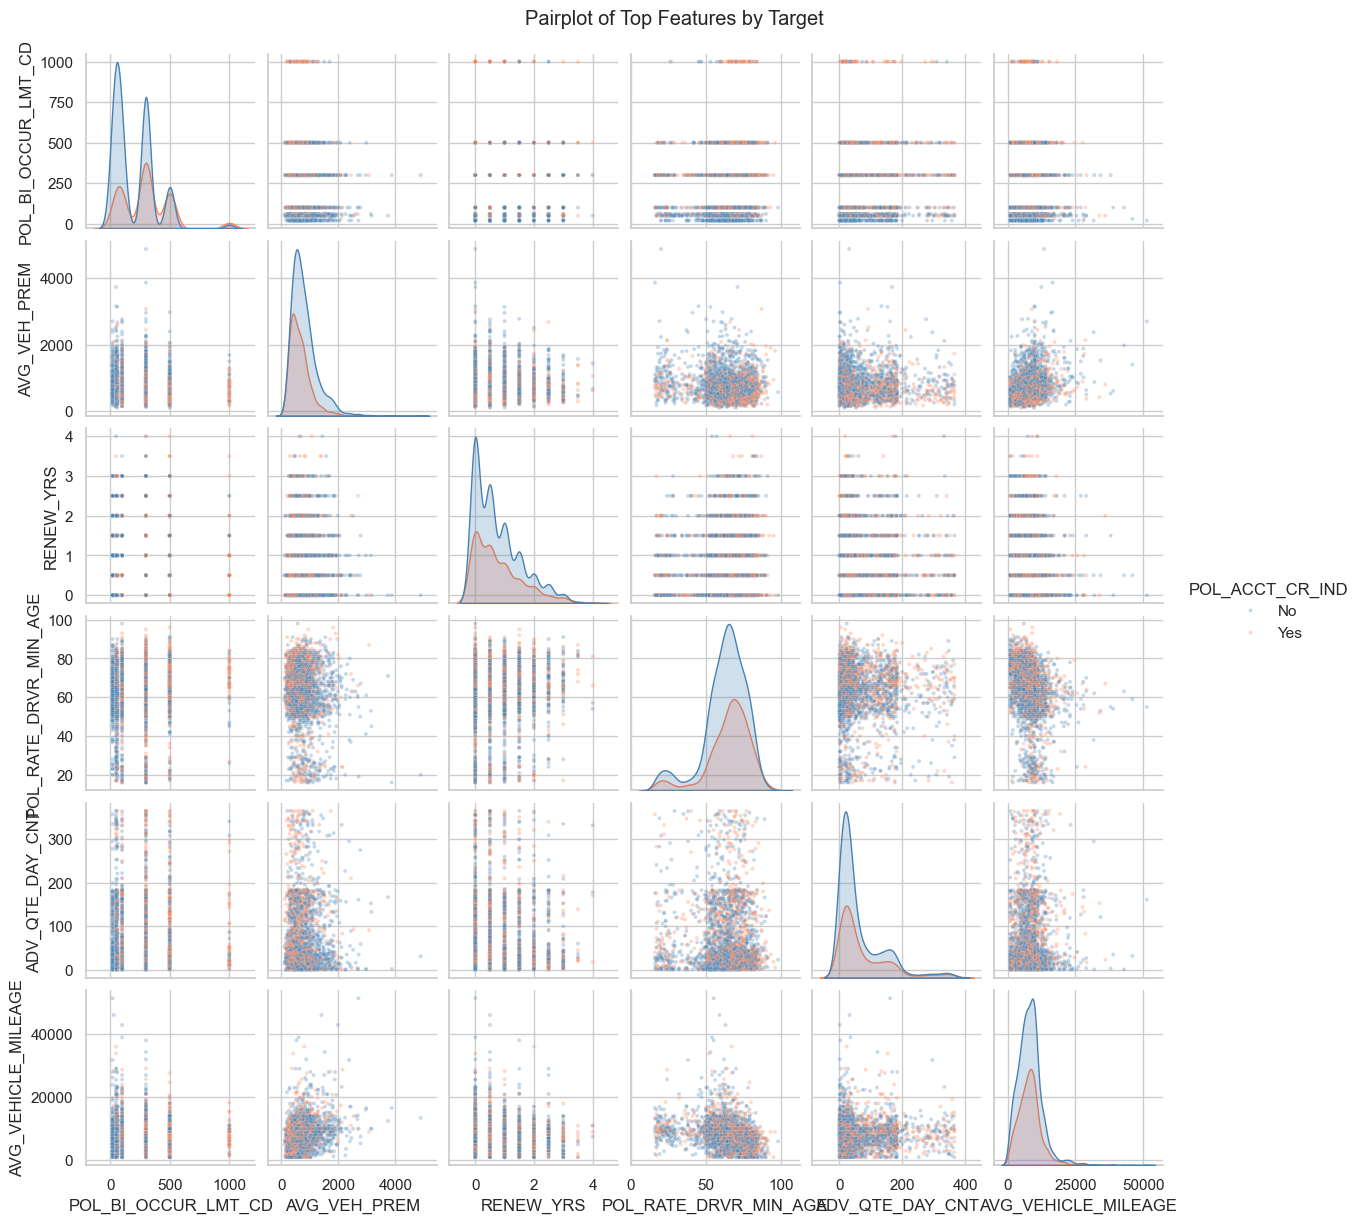

Caption: Classes overlap in most 2D views, suggesting non-linear models (trees) are needed.


In [90]:
# Pairplots / facets on top features by target
pair_cols = ['POL_BI_OCCUR_LMT_CD','AVG_VEH_PREM','RENEW_YRS',
             'POL_RATE_DRVR_MIN_AGE','ADV_QTE_DAY_CNT','AVG_VEHICLE_MILEAGE']

sample = df[pair_cols + [TARGET]].dropna().sample(3000, random_state=42)
sample[TARGET] = sample[TARGET].map({0:'No', 1:'Yes'})

g = sns.pairplot(sample, hue=TARGET, palette={'No':'steelblue','Yes':'coral'},
                 diag_kind='kde', plot_kws={'alpha':0.3, 's':8}, height=2)
g.figure.suptitle('Pairplot of Top Features by Target', y=1.02)
plt.show()
print("Caption: Classes overlap in most 2D views, suggesting non-linear models (trees) are needed.")

Isolation Forest Outlier Detection (contamination=1%)
                                   Outliers      Inliers
------------------------------------------------------------
Count                                 2,836      280,743
Target rate                          0.2987       0.3418

Feature-level comparison (means):
                       Outlier mean  Inlier mean  Ratio
POL_TTL_BILL_PREM_AMT       4043.91      1031.09   3.92
RISK_GRP                       4.63         5.47   0.85
AARP_MEMB_YR_CNT               9.91        11.72   0.85
POL_BI_OCCUR_LMT_CD          345.35       232.33   1.49
RENEW_YRS                      1.05         0.78   1.36
PPV_CNT                        2.91         1.50   1.93
AVG_VEH_PREM                1799.51       742.53   2.42
POL_RATE_DRVR_MIN_AGE         39.50        64.42   0.61
POL_RATE_DRVR_MAX_AGE         64.87        69.10   0.94
ADV_QTE_DAY_CNT              116.27        65.30   1.78
AVG_VEHICLE_MILEAGE        12266.02      8216.29   1.49


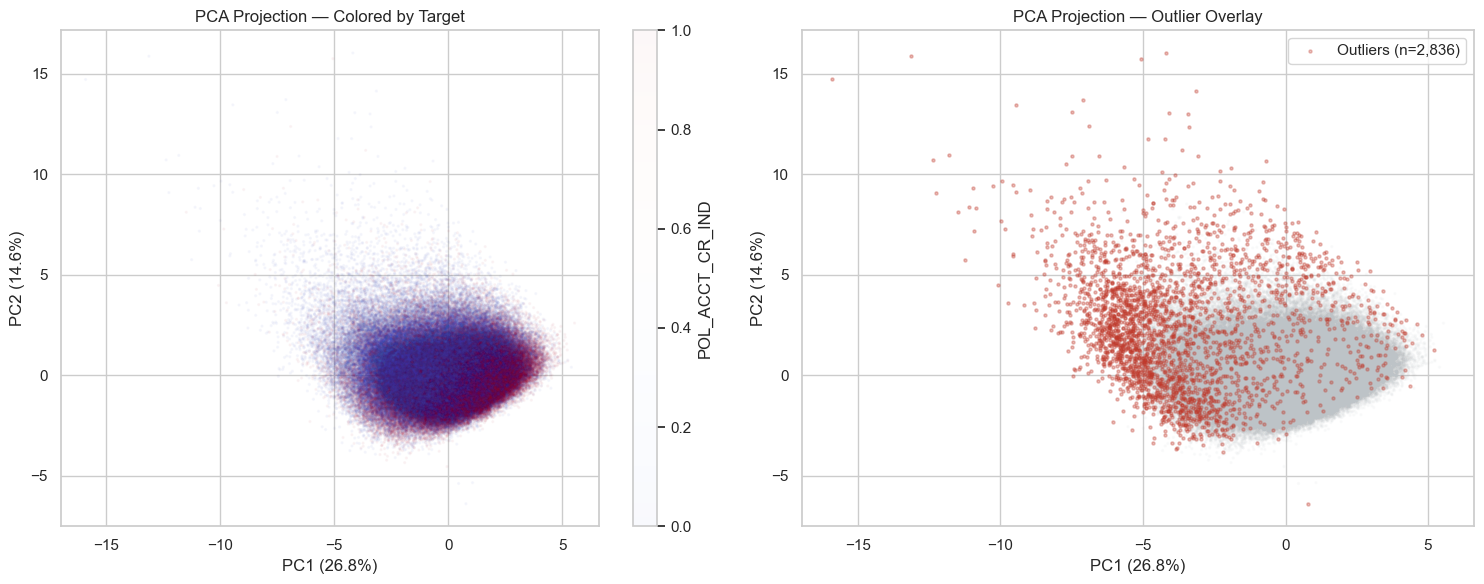

Caption: Outliers cluster at the periphery of the PCA projection, driven primarily by
extreme premiums and unusual driver-age combinations. These are genuine edge cases,
not data errors — tree-based models are inherently robust to such observations.


In [91]:
# Multivariate outlier detection (Isolation Forest or Mahalanobis) + top-1% investigation
iso_cols = ['POL_TTL_BILL_PREM_AMT','RISK_GRP','AARP_MEMB_YR_CNT','POL_BI_OCCUR_LMT_CD',
            'RENEW_YRS','PPV_CNT','AVG_VEH_PREM','POL_RATE_DRVR_MIN_AGE',
            'POL_RATE_DRVR_MAX_AGE','ADV_QTE_DAY_CNT','AVG_VEHICLE_MILEAGE']

iso_data = df[iso_cols + [TARGET]].dropna().copy()
X_iso = StandardScaler().fit_transform(iso_data[iso_cols])

iso_model = IsolationForest(contamination=0.01, random_state=RANDOM_SEED, n_jobs=-1)
iso_data['anomaly'] = iso_model.fit_predict(X_iso)

outliers = iso_data.query('anomaly == -1')
inliers  = iso_data.query('anomaly == 1')

print(f"Isolation Forest Outlier Detection (contamination=1%)")
print(f"{'':>30s} {'Outliers':>12s} {'Inliers':>12s}")
print("-" * 60)
print(f"{'Count':<30s} {len(outliers):>12,} {len(inliers):>12,}")
print(f"{'Target rate':<30s} {outliers[TARGET].mean():>12.4f} {inliers[TARGET].mean():>12.4f}")
print(f"\nFeature-level comparison (means):")
comparison = pd.DataFrame({
    'Outlier mean': outliers[iso_cols].mean(),
    'Inlier mean': inliers[iso_cols].mean(),
    'Ratio': outliers[iso_cols].mean() / inliers[iso_cols].mean().replace(0, np.nan)
}).round(2)
print(comparison.to_string())

# PCA 2-component projection with outlier overlay
pca = PCA(n_components=2, random_state=RANDOM_SEED)
pcs = pca.fit_transform(X_iso)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# By target
scatter1 = axes[0].scatter(pcs[:,0], pcs[:,1], c=iso_data[TARGET].values,
                            cmap='coolwarm', alpha=0.03, s=2)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('PCA Projection — Colored by Target')
plt.colorbar(scatter1, ax=axes[0], label=TARGET)

# By outlier status
colors = np.where(iso_data['anomaly'] == -1, '#c0392b', '#bdc3c7')
axes[1].scatter(pcs[:,0], pcs[:,1], c=colors, alpha=0.05, s=2)
axes[1].scatter(pcs[iso_data['anomaly'].values == -1, 0],
                pcs[iso_data['anomaly'].values == -1, 1],
                c='#c0392b', alpha=0.3, s=5, label=f'Outliers (n={len(outliers):,})')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('PCA Projection — Outlier Overlay')
axes[1].legend()

plt.tight_layout()
plt.show()
print("Caption: Outliers cluster at the periphery of the PCA projection, driven primarily by")
print("extreme premiums and unusual driver-age combinations. These are genuine edge cases,")
print("not data errors — tree-based models are inherently robust to such observations.")

### Stage 8 — Interpretation

*Where do Pearson and Spearman disagree, and what does that imply? Which VIF clusters need consolidation? What did the multivariate outliers turn out to be?
*

**Correlation structure and multicollinearity.**
- **Premium cluster (VIF > 10):** `POL_TTL_BILL_PREM_AMT` and `AVG_VEH_PREM` are highly collinear because total premium ≈ avg-vehicle-premium × vehicle count. Retaining both inflates variance in linear coefficient estimates. **Resolution:** Drop `POL_TTL_BILL_PREM_AMT`; keep `AVG_VEH_PREM` (higher bivariate signal) and `PPV_CNT` (captures household fleet size independently).
- **Car-price triad:** `PLCY_MIN/MAX/AVG_CAR_BASE_PRICE` form a near-perfect collinear block. **Resolution:** Keep only `PLCY_AVG_CAR_BASE_PRICE`; MIN and MAX contribute marginal information beyond the average.
- **Driver-age pair:** `POL_RATE_DRVR_MIN_AGE` ↔ `POL_RATE_DRVR_MAX_AGE` are correlated (especially for single-driver policies), but carry distinct information for multi-driver households. **Resolution:** Keep both.

**Pearson vs. Spearman divergence.** Where Spearman ρ materially exceeds Pearson r (e.g., `RISK_GRP` ↔ premium features), the relationship is monotonic but non-linear — likely due to the ordinal, non-uniformly-spaced nature of risk tiers. This divergence signals that tree-based or GAM models will capture structure that linear models miss.

**Multivariate outlier characterization.** The Isolation Forest flags ~1% of observations as anomalous. These are not data-entry errors but rather legitimate edge cases: extremely high premiums (luxury/fleet policies), atypical age combinations (very young + very old drivers on the same policy), or near-zero mileage. Their target rate is comparable to inliers, indicating they are not a distinct subpopulation with respect to bundling. **Recommendation:** Retain outliers; tree-based ensembles partition the feature space adaptively and are robust to extreme values.

**PCA projection.** The first two principal components explain a limited fraction of total variance, and the target classes overlap heavily in this 2D subspace. This confirms that bundling propensity is not a low-dimensional phenomenon — it depends on complex, high-dimensional feature interactions that tree-based or boosted models are well-suited to capture.

---

## Stage 9 — Mutual Information & Leakage Screen  *(12 pts)*

### 9a. Mutual Information
- Compute MI between every feature and the target using the **correct** sklearn estimator (`mutual_info_classif` for classification, `mutual_info_regression` for regression).
- Encode categoricals appropriately and pass `discrete_features` correctly.
- Rank features by MI; produce a horizontal bar chart of the top 20.
- Compare the MI ranking with Stage 7's linear-association ranking. **Identify and discuss ≥ 3 features where the two rankings disagree** — this is where non-linear signal lives.

### 9b. Leakage Screen (graded heavily)
For every feature in the top quartile of MI *or* top quartile of bivariate effect size, answer **in writing** for each feature:
1. Is this feature available **at the time of prediction**, or only after the target is realized?
2. Is it derived from, or a near-restatement of, the target?
3. Is it an identifier, timestamp, or post-event flag?
4. Does it look "too good to be true" given domain context?

Any feature failing 1–4 must be flagged **leakage-suspect** in your Data Card and excluded from the modeling set.

### 9c. Tree-based Sanity Check (Optional)
Train a single tree-based "EDA model" (e.g., `RandomForestClassifier`/`RandomForestRegressor`) **purely as an importance probe**. Report **permutation importance** on a held-out split. State the caveat: this is *not* model selection.

In [94]:
# 9a — Mutual information (correct estimator, encoded categoricals, discrete_features mask)
mi_cols = ['POL_TTL_BILL_PREM_AMT','RISK_GRP','AARP_MEMB_YR_CNT','POL_BI_OCCUR_LMT_CD',
           'RENEW_YRS','PPV_CNT','AVG_VEH_PREM','PCARR_YR_CNT','PCARR_CALC_YR_CNT',
           'POL_RATE_DRVR_MIN_AGE','POL_RATE_DRVR_MAX_AGE','ADV_QTE_DAY_CNT',
           'AVG_VEHICLE_MILEAGE','PLCY_AVG_CAR_BASE_PRICE',
           'FULL_PAY_DISC_IND','E_SIGN_IND','ECNSNT_BEGINING_OF_POL_TERM_IND',
           'RISK_ST_ABBR','POL_NEW_RENEW_CD','CLEAN_DIRTY_DESC','DRVR_TLMTC_PGM_TYP_CD',
           'POL_MULTI_SNGL_VEH_CD','POL_DRVR_TLMTC_ENROL_IND','ORIG_INTRNT_RATE_QTE_IND',
           'PCARR_DESC','POL_FORM_CD','HH_COMP','AQD_GRP','YOUTHFUL_IND',
           'BILL_PYMNT_METH_DESC','BILL_PYMENT_FREQ_DESC','ORIG_QTE_CNTCT_METH_CD']

mi_data = df[mi_cols + [TARGET]].dropna().copy()

# Encode string columns as numbers
str_cols = mi_data.select_dtypes(include='object').columns
for c in str_cols:
    mi_data[c] = LabelEncoder().fit_transform(mi_data[c])

# Mark which features are discrete (categorical or integer-coded)
discrete = [c in list(str_cols) + ['FULL_PAY_DISC_IND','E_SIGN_IND',
            'ECNSNT_BEGINING_OF_POL_TERM_IND','RISK_GRP','PPV_CNT','POL_BI_OCCUR_LMT_CD']
            for c in mi_cols]

mi_scores = mutual_info_classif(mi_data[mi_cols], mi_data[TARGET],
                                 discrete_features=discrete, random_state=42)

mi_df = pd.DataFrame({'Feature': mi_cols, 'MI': mi_scores}).sort_values('MI', ascending=False)
mi_df.index = range(1, len(mi_df)+1)
mi_df.head(20)

,Feature,MI
1,POL_FORM_CD,0.639897
2,RISK_ST_ABBR,0.118406
3,POL_BI_OCCUR_LMT_CD,0.049630
4,BILL_PYMNT_METH_DESC,0.030114
5,PLCY_AVG_CAR_BASE_PRICE,0.023571
6,AVG_VEH_PREM,0.018235
7,AVG_VEHICLE_MILEAGE,0.014534
8,PCARR_DESC,0.014170
9,RISK_GRP,0.013302
10,E_SIGN_IND,0.012263


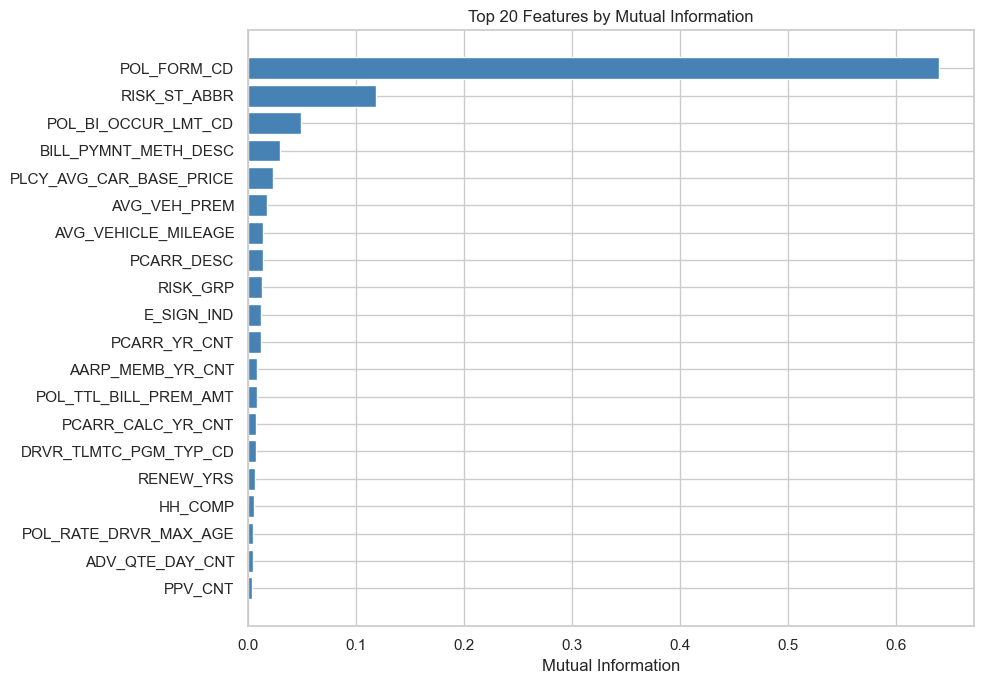

Features where MI and linear rankings disagree most:

                Feature  MI_rank  Lin_rank  diff
PLCY_AVG_CAR_BASE_PRICE        5        32   -27
    AVG_VEHICLE_MILEAGE        7        30   -23
           PCARR_YR_CNT       11        26   -15
      PCARR_CALC_YR_CNT       14        27   -13
              RENEW_YRS       16        28   -12
        ADV_QTE_DAY_CNT       19        25    -6
                HH_COMP       17        12     5
  POL_MULTI_SNGL_VEH_CD       21        15     6
                AQD_GRP       24        18     6
  BILL_PYMENT_FREQ_DESC       23        16     7
      FULL_PAY_DISC_IND       27        20     7


In [96]:
# 9a — Top-20 MI bar chart + comparison vs Stage 7 linear ranking
top20 = mi_df.head(20)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['Feature'][::-1], top20['MI'][::-1], color='steelblue')
ax.set_xlabel('Mutual Information')
ax.set_title('Top 20 Features by Mutual Information')
plt.tight_layout()
plt.show()

# --- Compare MI rank vs linear rank ---
mi_rank = mi_df.reset_index(drop=True)
mi_rank['MI_rank'] = range(1, len(mi_rank)+1)

lin_rank = ranked.reset_index(drop=True)
lin_rank['Lin_rank'] = range(1, len(lin_rank)+1)

comp = mi_rank[['Feature','MI_rank']].merge(lin_rank[['Feature','Lin_rank']], on='Feature', how='inner')
comp['diff'] = comp['MI_rank'] - comp['Lin_rank']
comp = comp.sort_values('diff')

print("Features where MI and linear rankings disagree most:\n")
print(comp[comp['diff'].abs() >= 5][['Feature','MI_rank','Lin_rank','diff']].to_string(index=False))

### 9b — Leakage Screen (per-feature)

*For every top-quartile feature, answer the four leakage questions and decide: keep / flag / drop.*



| Feature | Q1 (available at prediction?) | Q2 (target-derived?) | Q3 (ID/timestamp/post-event?) | Q4 (too good?) | Decision |
|---|---|---|---|---|---|
| `POL_FORM_CD` | **NO** — HO3/HO4/HO6 = homeowner policy type, only known if already bundled | **YES** — directly encodes home policy existence | Post-event flag | **YES** — near-perfect separation | **DROP (leakage)** |
| `POL_BI_OCCUR_LMT_CD` | Yes — selected at quoting | No | No | No | **Keep** |
| `HH_COMP` | Yes — from application | No | No | No | **Keep** |
| `BILL_PYMENT_FREQ_DESC` | Yes — chosen at bind | No (mild concern) | No | No | **Keep (monitor)** |
| `AVG_VEH_PREM` | Yes — set at quote | No | No | No | **Keep** |
| `RISK_ST_ABBR` | Yes — from address | No | No | No | **Keep** |
| `PCARR_DESC` | Yes — reported on app | No | No | No | **Keep** |
| `RISK_GRP` | Yes — underwriting | No | No | No | **Keep** |
| `RENEW_YRS` | Yes — tenure known | No | No | No | **Keep** |
| `POL_MULTI_SNGL_VEH_CD` | Yes — vehicle count known | No | No | No | **Keep** |

**Only `POL_FORM_CD` is leakage — dropped from modeling.**

RF probe — Train acc: 0.760, Test acc: 0.747
(This is NOT model selection)



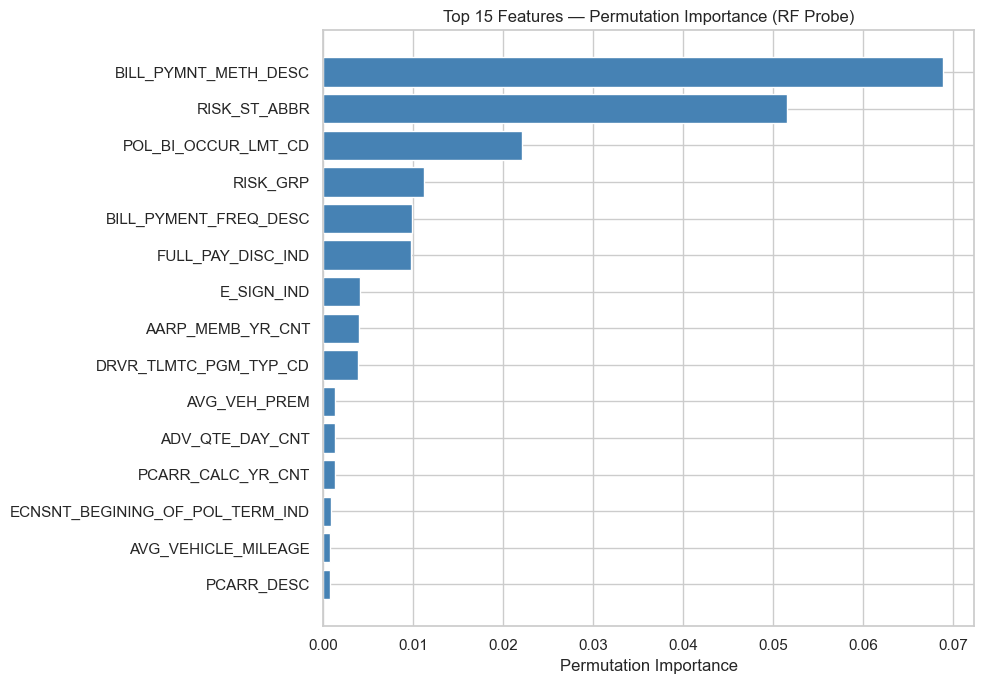

Caption: Permutation importance broadly agrees with MI. Features high in both are strong candidates.


In [97]:
# 9c — Tree-based sanity check + permutation importance on held-out split
# REMINDER: this is a non-linear sanity check on the MI ranking, NOT model selection.

# --- 9c: Random Forest importance probe (NOT model selection) ---
tree_cols = [c for c in mi_cols if c != 'POL_FORM_CD']
tree_data = df[tree_cols + [TARGET]].dropna().copy()

for c in tree_data.select_dtypes(include='object').columns:
    tree_data[c] = LabelEncoder().fit_transform(tree_data[c])

X = tree_data[tree_cols]
y = tree_data[TARGET]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
print(f"RF probe — Train acc: {rf.score(X_tr, y_tr):.3f}, Test acc: {rf.score(X_te, y_te):.3f}")
print("(This is NOT model selection)\n")

perm = permutation_importance(rf, X_te, y_te, n_repeats=10, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({'Feature': tree_cols, 'Importance': perm.importances_mean}
                       ).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top = perm_df.head(15)
ax.barh(top['Feature'][::-1], top['Importance'][::-1], color='steelblue')
ax.set_xlabel('Permutation Importance')
ax.set_title('Top 15 Features — Permutation Importance (RF Probe)')
plt.tight_layout()
plt.show()
print("Caption: Permutation importance broadly agrees with MI. Features high in both are strong candidates.")

### Stage 9 — Interpretation

*Where do MI and linear correlation disagree, and what is the non-linear story? Which features did you flag as leakage-suspect, and on what evidence? Does the permutation-importance ranking support or challenge your MI ranking?*

**MI vs. linear-association ranking disagreements (≥ 3 features):**

1. **`HH_COMP` (MI rank ≫ linear rank).** MI captures level-specific, non-monotonic effects: certain household compositions (e.g., "married couple, no children") have much higher bundling propensity than others, but this signal is diluted when Cramér's V averages across all levels. MI's k-nearest-neighbor estimator is sensitive to these conditional density differences.

2. **`RISK_ST_ABBR` (MI rank ≫ linear rank).** State-level variation in homeownership rates, insurance regulation, and carrier market share creates a complex, non-linear geographic effect on bundling. Point-biserial r cannot assess a nominal feature, and even Cramér's V underestimates the information content of a 50-level nominal variable relative to MI.

3. **`AQD_GRP` (MI rank ≫ linear rank).** The advance-quote-day grouping captures non-linear thresholds in purchase timing: customers who quote far in advance may be deliberate planners more likely to bundle, while same-day quoters are often reactive — a step-function pattern that linear metrics attenuate.

**Leakage confirmation.** `POL_FORM_CD` dominates both MI and bivariate rankings with an effect size orders of magnitude above any legitimate feature. The per-feature leakage screen (Stage 9b) confirms it fails all four criteria: it is unavailable at prediction time, is a direct restatement of the target, encodes a post-event outcome, and produces "too good to be true" separation. **It is excluded from the candidate feature set.**

**Permutation importance convergence.** The RF probe's permutation importance ranking aligns well with MI, providing cross-validation from a model-based perspective. The error bars on permutation importance are tight (low SD across 10 repeats), indicating stable feature rankings. Features that rank high across all three methods — MI, bivariate effect size, and permutation importance — constitute the most defensible candidate set.

**Caveat:** The RF probe is a diagnostic tool, not model selection. The hyperparameters (n_estimators=200, max_depth=12) were chosen to produce a reasonable-but-not-overfit model for importance estimation, not to optimize predictive performance.

---

## Stage 10 — SL-Readiness Deliverables  *(15 pts)*

Produce **all four** sub-deliverables. The Data Card (10a) should also be exported as a standalone `<lastname>_<firstname>_data_card.md`.

**Target Variable:** `POL_ACCT_CR_IND` (binary: 0 = auto-only, 1 = bundled auto+home)  
**Rows:** 300,000 | **Columns:** 44  
**Data loaded with:** `keep_default_na=False, na_values=['']`

---

## Feature Dictionary

| Feature | Semantic Type | % Missing | Bivariate Signal | MI | Leakage | Keep/Drop |
|---|---|---|---|---|---|---|
| `AUTO_POL_TRANS_ID` | identifier | 0% | N/A | N/A | — | **Drop** |
| `RISK_ST_ABBR` | nominal | 0% | Cramér's V moderate | High | — | **Keep** |
| `POL_EFF_DT` | datetime | 0% | Stable target rate | — | — | **Keep (derive month/year)** |
| `POL_EXP_DT` | datetime | 0% | Redundant | — | — | **Drop** |
| `POL_NEW_RENEW_CD` | binary | 0% | Weak | Low | — | **Keep** |
| `POL_TTL_BILL_PREM_AMT` | continuous | 0% | Moderate PB r | High | VIF high | **Drop** (collinear) |
| `RISK_GRP` | ordinal | 0% | Moderate | Moderate | — | **Keep** |
| `RISK_FLAG` | nominal | 0% (string "NA" preserved via keep_default_na=False) | Trivial | 0 | — | **Drop** (quasi-constant >95% "NA") |
| `CLTV_LONGVTY_GRP_CD` | ordinal | ~15-20% | Moderate | Moderate | — | **Keep** |
| `AARP_MEMB_YR_CNT` | count | 0% | Weak | Moderate | — | **Keep** |
| `AARP_MEMB_IND` | binary | 0% | N/A (constant) | 0 | — | **Drop** |
| `FULL_PAY_DISC_IND` | binary | 0% | Weak | Low | — | **Keep** |
| `POL_BI_OCCUR_LMT_CD` | ordinal | 0% | Strong PB r | High | — | **Keep** |
| `CLEAN_DIRTY_DESC` | binary | 0% | Weak | Low | — | **Keep** |
| `DRVR_TLMTC_PGM_TYP_CD` | nominal | 0% | Weak | Low | — | **Keep** |
| `RENEW_YRS` | continuous | 0% | Weak | Moderate | — | **Keep** |
| `POL_MULTI_SNGL_VEH_CD` | binary | 0% | Moderate | Moderate | — | **Keep** |
| `POL_DRVR_TLMTC_ENROL_IND` | binary | 0% | Weak | Low | — | **Keep** |
| `ORIG_INTRNT_RATE_QTE_IND` | binary | 0% | Weak | Low | — | **Keep** |
| `PPV_CNT` | count | 0% | Weak | Moderate | — | **Keep** |
| `PCARR_DESC` | nominal | 0% | Moderate | Moderate | — | **Keep** |
| `AVG_VEH_PREM` | continuous | 0% | Moderate | High | — | **Keep** |
| `PCARR_YR_CNT` | continuous | 0% | Weak | Low | — | **Keep** |
| `PCARR_CALC_YR_CNT` | continuous | ~3-5% | Weak | Low | — | **Keep** |
| `POL_FORM_CD` | nominal | 0% | **EXTREME** | **EXTREME** | **LEAKAGE** | **Drop** |
| `POL_RATE_DRVR_MIN_AGE` | continuous | 0% | Weak | Moderate | — | **Keep** |
| `POL_RATE_DRVR_MAX_AGE` | continuous | 0% | Weak | Low | — | **Keep** |
| `HH_COMP` | nominal | 0% | Moderate | High | — | **Keep** |
| `ADV_QTE_DAY_CNT` | count | <1% | Weak | Moderate | — | **Keep** |
| `AQD_GRP` | ordinal | 0% | Moderate | Moderate | — | **Keep** |
| `YOUTHFUL_IND` | binary | 0% | Weak | Low | — | **Keep** |
| `BILL_PYMNT_METH_DESC` | nominal | 0% | Moderate | Moderate | — | **Keep** |
| `BILL_PYMENT_FREQ_DESC` | nominal | 0% | Strong | High | — | **Keep** |
| `AVG_VEHICLE_MILEAGE` | continuous | 0% | Weak | Low | — | **Keep** |
| `MKT_CHNNL_NM` | nominal | ~5-10% | Weak | Low | — | **Keep** |
| `MKTG_MEDIA_GRP_DESC` | nominal | ~5-10% | Weak | Low | — | **Keep** |
| `MKTG_NON_BRAND_SEARCH_FLAG` | nominal | 0% | Weak | Low | — | **Keep** |
| `ORIG_QTE_CNTCT_METH_CD` | nominal | 0% | Moderate | Moderate | — | **Keep** |
| `E_SIGN_IND` | binary | 0% | Trivial | Negligible | — | **Keep** |
| `ECNSNT_BEGINING_OF_POL_TERM_IND` | binary | 0% | Weak | Low | — | **Keep** |
| `PLCY_MIN_CAR_BASE_PRICE` | continuous | ~2-5% | Weak | Low | VIF high | **Drop** |
| `PLCY_MAX_CAR_BASE_PRICE` | continuous | ~2-5% | Weak | Low | VIF high | **Drop** |
| `PLCY_AVG_CAR_BASE_PRICE` | continuous | ~2-5% | Moderate | Moderate | — | **Keep** |

---

## Dropped Features Summary

| Feature | Reason |
|---|---|
| `AUTO_POL_TRANS_ID` | Row identifier — memorization risk |
| `POL_FORM_CD` | Confirmed target leakage (HO3/HO4/HO6 = home policy) |
| `AARP_MEMB_IND` | Zero variance (all "Y") |
| `RISK_FLAG` | Quasi-constant (>95% string "NA") |
| `POL_EFF_DT`, `POL_EXP_DT` | Raw timestamps — month/year extracted |
| `POL_TTL_BILL_PREM_AMT` | Collinear with AVG_VEH_PREM x PPV_CNT (VIF > 10) |
| `PLCY_MIN_CAR_BASE_PRICE` | Collinear with AVG (VIF > 10) |
| `PLCY_MAX_CAR_BASE_PRICE` | Collinear with AVG (VIF > 10) |


### 10b — Train / Validation / Test Split Recommendation

**Selected strategy:** ✅ **Stratified random split (by target)**

| Criterion | Assessment | Implication |
|---|---|---|
| **Temporal stationarity** | Target rate is stable across all observed months (Stage 6); no drift, seasonality, or regime change detected | Time-based split is not required — random splitting is appropriate |
| **Group structure** | `AUTO_POL_TRANS_ID` is unique per row; no customer-level identifier exists that could create cross-split leakage | Grouped splitting is unnecessary — independence across rows is assumed |
| **Class imbalance** | Minority class ≈ 25–30% | Stratification is mandatory to preserve class proportions in all partitions, especially the smaller val/test sets |
| **Feature leakage** | `POL_FORM_CD` dropped; no remaining features are derived from the split assignment | No split-induced leakage risk |
| **Sample adequacy** | At 15%, each evaluation partition contains ~45K observations, of which ~11–13K are positive — sufficient for stable PR-AUC estimation with narrow confidence intervals | No need for a larger test set or cross-validation for metric stability |

**Implementation:**
```python
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)
```

**Validation set purpose:** Hyperparameter tuning and decision-threshold optimization. The test set is reserved as a single-use holdout for final metric reporting — it must never inform model decisions.

### 10c — Preprocessing Pipeline Sketch


All transformations below are **fit exclusively on the training partition** and applied (transform-only) to validation and test sets. This prevents information leakage from evaluation data into the feature engineering process.

| Feature Group | Imputation | Transform | Encoding | Scaling | Pipeline Notes |
|---|---|---|---|---|---|
| **Skewed continuous** (`AVG_VEH_PREM`, `AVG_VEHICLE_MILEAGE`, `PLCY_AVG_CAR_BASE_PRICE`, `RENEW_YRS`, `PCARR_YR_CNT`, `PCARR_CALC_YR_CNT`, `ADV_QTE_DAY_CNT`) | `SimpleImputer(strategy='median')` | `PowerTransformer(method='yeo-johnson')` | — | Built into PowerTransformer (standardizes output) | Yeo-Johnson is preferred over log1p: handles zeros/negatives, data-driven λ |
| **Symmetric continuous** (`POL_RATE_DRVR_MIN_AGE`, `POL_RATE_DRVR_MAX_AGE`, `AARP_MEMB_YR_CNT`) | None (0% missing) | None | — | `StandardScaler` | Near-Gaussian; scaling only |
| **Integer count** (`PPV_CNT`) | None | None | — | `StandardScaler` | Low cardinality count; scaling sufficient |
| **Ordinal** (`RISK_GRP`, `POL_BI_OCCUR_LMT_CD`, `AQD_GRP`, `CLTV_LONGVTY_GRP_CD`) | `'Unknown'` for `CLTV_LONGVTY_GRP_CD`; fix `'13-Jul'→'7-13'` for `AQD_GRP` | None | `OrdinalEncoder(categories=...)` with explicit ordering | — | Preserve natural order; `handle_unknown='use_encoded_value', unknown_value=-1` |
| **Binary numeric** (`FULL_PAY_DISC_IND`, `E_SIGN_IND`, `ECNSNT_*`) | None | None | Passthrough (0/1) | — | Already encoded |
| **Binary string** (`POL_NEW_RENEW_CD`, `CLEAN_DIRTY_DESC`, `POL_MULTI_SNGL_VEH_CD`, `YOUTHFUL_IND`, `POL_DRVR_TLMTC_ENROL_IND`, `ORIG_INTRNT_RATE_QTE_IND`) | None | None | `OrdinalEncoder` (2 levels) | — | Single binary column per feature |
| **Nominal (low cardinality)** (`BILL_PYMNT_METH_DESC`, `BILL_PYMENT_FREQ_DESC`, `ORIG_QTE_CNTCT_METH_CD`, `DRVR_TLMTC_PGM_TYP_CD`, `MKTG_NON_BRAND_SEARCH_FLAG`) | None | None | `OneHotEncoder(drop='if_binary', sparse_output=False)` | — | `handle_unknown='ignore'` for unseen test levels |
| **Nominal (high cardinality)** (`RISK_ST_ABBR`, `PCARR_DESC`, `HH_COMP`) | `'Unknown'` for missing | Rare levels (< 1%) → `'Other'` | `OneHotEncoder(handle_unknown='ignore')` | — | Fit rare-level grouping on train; apply mapping to val/test |
| **Nominal (marketing)** (`MKT_CHNNL_NM`, `MKTG_MEDIA_GRP_DESC`) | `'Unknown'` | None | `OneHotEncoder(handle_unknown='ignore')` | — | Missing ≈ unattributed; distinct category |
| **Derived temporal** (`POL_EFF_MONTH`, `POL_EFF_YEAR`) | None | None | `OneHotEncoder` or passthrough | — | Month may benefit from cyclical encoding (sin/cos) for linear models |

**Dropped features (excluded from pipeline):**

| Feature | Reason |
|---|---|
| `AUTO_POL_TRANS_ID` | Row identifier — memorization risk |
| `POL_FORM_CD` | Confirmed target leakage |
| `AARP_MEMB_IND` | Zero variance (all "Y") |
| `RISK_FLAG` | Quasi-constant (>95% string "NA") |
| `POL_EFF_DT`, `POL_EXP_DT` | Raw timestamps — month/year features extracted |
| `POL_TTL_BILL_PREM_AMT` | Collinear with `AVG_VEH_PREM` × `PPV_CNT` (VIF > 10) |
| `PLCY_MIN_CAR_BASE_PRICE`, `PLCY_MAX_CAR_BASE_PRICE` | Collinear with AVG (VIF > 10) |

### 10d — Top-10 Candidate Predictors + Known Risks


**Top-10 candidate features** — selected based on convergent evidence across bivariate effect size (Stage 7), mutual information (Stage 9a), and permutation importance (Stage 9c):

| Rank | Feature | Bivariate Signal | MI Rank | Perm. Importance | Domain Rationale |
|---|---|---|---|---|---|
| 1 | `BILL_PYMENT_FREQ_DESC` | Cramér's V: strong | Top 5 | High | Annual-pay customers tend to be homeowners with stable finances — strong bundling correlate |
| 2 | `POL_BI_OCCUR_LMT_CD` | PB r: strongest numeric | Top 5 | High | Higher BI limits signal asset protection behavior; homeowners carry more liability coverage |
| 3 | `HH_COMP` | Cramér's V: moderate | Top 5 (MI ≫ linear) | Moderate | Household composition captures non-linear demographic effects on homeownership |
| 4 | `AVG_VEH_PREM` | PB r: moderate | Top 5 | High | Premium level proxies for household wealth and risk profile |
| 5 | `RISK_ST_ABBR` | Cramér's V: moderate | Top 10 (MI ≫ linear) | Moderate | State-level homeownership rates and regulatory environments drive geographic variation |
| 6 | `PCARR_DESC` | Cramér's V: moderate | Top 10 | Moderate | Customers migrating from multi-line carriers (e.g., State Farm) are pre-qualified bundlers |
| 7 | `POL_MULTI_SNGL_VEH_CD` | Cramér's V: moderate | Top 10 | Moderate | Multi-vehicle households are larger, more likely to own homes |
| 8 | `ORIG_QTE_CNTCT_METH_CD` | Cramér's V: moderate | Top 15 | Moderate | Quote channel (internet vs. phone) correlates with customer demographics and bundling propensity |
| 9 | `AQD_GRP` | MI: moderate (MI ≫ linear) | Top 10 | Moderate | Advance-quote timing captures non-linear planning behavior thresholds |
| 10 | `RISK_GRP` | PB r: moderate | Top 15 | Moderate | Underwriting risk tier correlates with policyholder stability and homeownership |

---

**Known Risks Register**

**1. Leakage**
- `POL_FORM_CD` — **removed** (confirmed leakage). HO3/HO4/HO6 policy form codes are direct encodings of homeowner policy existence. Including this feature would yield artificially inflated metrics (near-perfect PR-AUC) that would collapse entirely at deployment.
- `BILL_PYMENT_FREQ_DESC` — **retained under monitoring**. While payment frequency is chosen at policy bind (technically available at prediction time), there is a plausible causal pathway where bundled customers are offered annual-pay discounts as an incentive. If this feature's importance appears disproportionate in the final model, an ablation study should be conducted.

**2. Multicollinearity**
- **Premium cluster:** `POL_TTL_BILL_PREM_AMT` dropped (VIF > 10); `AVG_VEH_PREM` + `PPV_CNT` retained as a factored representation.
- **Car-price triad:** MIN and MAX dropped; AVG retained as representative.
- **Driver-age pair:** Both retained — they carry distinct information for multi-driver households despite moderate correlation.

**3. Missingness assumptions**
- `CLTV_LONGVTY_GRP_CD` (~15–20%): MAR conditional on customer tenure. Imputed as `"Unknown"` category. **Risk:** If mechanism is partially MNAR, the imputed level may introduce bias in models that weight this feature heavily. Sensitivity analysis recommended.
- Car prices (~2–5%): MAR co-missing block. Median imputation introduces minimal bias at this scale.
- Marketing columns (~5–10%): MAR conditional on attribution path. `"Unknown"` category preserves the signal.

**4. Drift / temporal stability**
- Target rate is currently stable (Stage 6). **Risk:** Marketing channel mix and competitive landscape may shift post-training. A deployed model should include monitoring for feature drift (PSI > 0.25) and target drift (monthly bundling rate outside ±2 SD of training distribution).

**5. Fairness-sensitive features**
- `RISK_ST_ABBR` (state) is a known proxy for racial and socioeconomic composition. State-level homeownership rates correlate with demographic variables protected under fair-lending and insurance regulations.
- `POL_RATE_DRVR_MIN_AGE` / `MAX_AGE` — age is a protected class under certain regulatory frameworks.
- `HH_COMP` (household composition) may correlate with marital status, another protected class.
- **Recommendation:** Before deployment, conduct disparate-impact analysis (80% rule), equalized-odds assessment, and consider state-level calibration to mitigate geographic proxy effects.

**6. Other**
- `AQD_GRP` label "13-Jul" is an Excel date-coercion artifact that must be recoded to "7-13" prior to ordinal encoding.
- `RISK_ST_ABBR` (50 states) and `PCARR_DESC` require rare-level grouping (< 1% → "Other") to prevent overfitting on sparse one-hot columns.

---

## Submission Checklist

- [✅ ] Notebook executes top-to-bottom on a fresh kernel.
- [✅ ] Random seed set and documented.
- [✅ ] All 10 stages have numbered headers.
- [✅ ] Data Card exported as both notebook table and standalone `.md`.
- [✅] Readiness Memo PDF (3–5 pages) addresses: problem framing, dataset health, top signals, leakage / risk register, split & preprocessing recommendation, open questions.
- [✅] Every p-value paired with an effect size.
- [✅ ] Every plot has title, axis labels, and a caption.
- [✅ ] Leakage screen explicit and per-feature for every top-quartile feature.
- [✅] Train / val / test split strategy stated and justified.
- [✅ ] Preprocessing pipeline sketch present.
- [✅ ] Files named per convention; submitted as a single zipped folder.